# **Домашнее задание 7: Fraud Detection Competition**

Добро пожаловать на финальное домашнее задание курса! Домашнее задание направлено на систематизацию всех знаний, полученных в процессе учебы.

В нём Вы потренируетесь применять навыки построения пайплайнов машинного обучения, приобретенные в курсе от точки разведочного анализа данных до построения и валидации моделей машинного обучения.

## **Задача**
**Вы будете решать задачу определения фрода:**

https://www.kaggle.com/competitions/fraud-detection-24

**Вам нужно будет:**
- в jupyter notebook провести исследование данных;
- в нём же построить модели и оценить их качество;
- отправить посылку на Kaggle.

Более подробное описание шагов - в ноутбуке ниже.

## **Оценивание и баллы**
- В EDA и во всей работе будут оцениваться полнота и **выводы**;
- При обучении моделей старайтесь обоснованно подходить к их выбору, избегая простого перебора;

**Максимальный балл** - 10 (+ бонусы за Kaggle, см. ниже).


Мягкий дедлайн (окончание соревнования на Kaggle): **15 марта 23:59**


In [ ]:
# Скачиваем файлы с Kaggle
!pip install kaggle -q

In [ ]:
# Убедимся, что директория для API ключа Kaggle существует
!mkdir -p ~/.kaggle

In [ ]:
# Скачиваем файлы соревнования
!kaggle competitions download -c fraud-detection-24 -p data
!unzip -o data/fraud-detection-24.zip -d ./

fraud-detection-24.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  data/fraud-detection-24.zip
  inflating: ./sample_submission.csv  
  inflating: ./test_identity.csv     
  inflating: ./test_transaction.csv  
  inflating: ./train_identity.csv    
  inflating: ./train_transaction.csv  


In [ ]:
!wget --no-check-certificate 'https://www.dropbox.com/s/5iuef7c9ljj84t6/train_transaction.csv?dl=0' -O train_transaction.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/cmy01z5fw7ohlmd/train_identity.csv?dl=0' -O train_identity.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/7thqkuxnwsa7njj/test_transaction.csv?dl=0' -O test_transaction.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/b40nvbb9e2usd5w/test_identity.csv?dl=0' -O test_identity.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/arkyoz0bel8z4d2/sample_submission.csv?dl=0' -O sample_submission.csv

# **Базовое решение и пример формирования файла под submission**


In [ ]:
!pip install catboost -q

In [ ]:
from catboost import CatBoostClassifier
import pandas as pd
import os
from tqdm import tqdm

INPUT_DIR = '.'

train_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(INPUT_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(INPUT_DIR, 'test_identity.csv'))
sample_submission = pd.read_csv(os.path.join(INPUT_DIR, 'sample_submission.csv'))

df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')

df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

In [ ]:
df_train.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_train.shape, df_test.shape

((417559, 432), (172981, 431))

In [ ]:
object_cols = []
for idx, col in tqdm(enumerate(df_train.columns.drop('isFraud'))):
    if df_train[col].dtype == 'O':
      object_cols.append(idx)

431it [00:00, 21214.93it/s]


In [ ]:
X_train = df_train.drop('isFraud', axis=1)
X_train = X_train.fillna('')
y_train = df_train['isFraud'].values

cb = CatBoostClassifier(iterations=3)
cb.fit(X_train, y_train, object_cols, )

Learning rate set to 0.5
0:	learn: 0.2082395	total: 1.46s	remaining: 2.92s
1:	learn: 0.1360790	total: 2.57s	remaining: 1.28s
2:	learn: 0.1180984	total: 4.06s	remaining: 0us


In [ ]:
predictions = cb.predict_proba(df_test.fillna(''))

In [ ]:
sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 0]})
sub.head()

,TransactionID,isFraud
0,3404559,0.978714
1,3404560,0.935724
2,3404561,0.946864
3,3404562,0.978714
4,3404563,0.970637


In [ ]:
# Сохранение submission
sub.to_csv('submission_baseline.csv', index=False)

### **Примечания:**

**1. Оценка качества и Submission File**
- Ответом является число от 0 до 1, метрикой качества - AUC-ROC.
- Структура Submission File:
 - для каждого значения *TransactionID* в тестовых данных вы должны предсказать **вероятность** для столбца *isFraud*.
 - в файле у вас должно быть две колонки: `TransactionID` и`isFraud`  **для каждой транзакции в датасете**.

**2. Объем данных**

Поскольку набор данных объемный, могут быть проблемы с переполнением памяти в Collab. Для решения проблемы можете использовать функцию из [этого ноутбука](https://colab.research.google.com/drive/18u75eyFGEoyeWJ_MbsLkcPa6gv2tNI8G#scrollTo=V2L1Nl5CTMMl), разобравшись, что она делает с данными.

# **Задание 1 (2 балла)**

Проведите EDA (разведочный анализ данных):
* проанализируйте признаки, их особенности и связь с целевой переменной
* проанализируйте целевую переменную
* оцените степень попарной взаимосвязи признаков, а также связи признаков и целевой переменной
* по результатам исследований сделайте необходимую обработку данных (удаление дублей, работа с пропусками, с категориальными столбцами (если они есть), работа с аномалиями, другие преобразования признаков)

Важно, что EDA всегда сопровождается выводами - не забудьте об этом.

In [ ]:
!pip install category_encoders -q

In [ ]:
!pip install catboost -q
!pip install lightgbm -q

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import time
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import re
from sklearn.metrics import classification_report

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, roc_auc_score
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import OneHotEncoder

sns.set()

%matplotlib inline

In [ ]:
INPUT_DIR = '.'

train_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(INPUT_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(INPUT_DIR, 'test_identity.csv'))
sample_submission = pd.read_csv(os.path.join(INPUT_DIR, 'sample_submission.csv'))

In [ ]:
train_transaction.shape, train_identity.shape, test_transaction.shape, test_identity.shape

((417559, 394), (110666, 41), (172981, 393), (33567, 41))

In [ ]:
train_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417559 entries, 0 to 417558
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.2+ GB


In [ ]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110666 entries, 0 to 110665
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  110666 non-null  int64  
 1   id_01          110666 non-null  float64
 2   id_02          108160 non-null  float64
 3   id_03          49500 non-null   float64
 4   id_04          49500 non-null   float64
 5   id_05          105299 non-null  float64
 6   id_06          105299 non-null  float64
 7   id_07          3945 non-null    float64
 8   id_08          3945 non-null    float64
 9   id_09          56554 non-null   float64
 10  id_10          56554 non-null   float64
 11  id_11          108273 non-null  float64
 12  id_12          110666 non-null  object 
 13  id_13          96110 non-null   float64
 14  id_14          64072 non-null   float64
 15  id_15          108273 non-null  object 
 16  id_16          99590 non-null   object 
 17  id_17          107259 non-nul

In [ ]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


В данных много пропусков. Также типы данных в столбцах неоптимизированны, из-за чего train_transaction весит свыше 1,2 ГБ. Стоит привести данные к оптимизированным типам

Объединю таблицы и приведу данные в них к оптимизированным типам

In [ ]:
df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')
df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

In [ ]:
del train_transaction, train_identity, test_transaction, test_identity

In [ ]:
df_train.shape

(417559, 434)

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417559 entries, 0 to 417558
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.4+ GB


Оптимизирую датасет и заполню пропуски в нем

In [ ]:
# Функция для оптимизации типов взята из https://colab.research.google.com/drive/1iOloUogDTWGLQceR1gkkVfVccSpDs_E0#scrollTo=VGs-EFXQMW4u&line=6&uniqifier=1
# Немного исправил функцию, т.к. возникали ошибки при запуске

def reduce_mem_usage(df):
    NAlist = [] # Keeps track of columns that have missing values filled in.
    for col in tqdm(df.columns):
        if df[col].dtype != object:  # Exclude strings

            # make variables for Int, max and min
            IsInt = False
            col_max_value = df[col].max()
            col_min_value = df[col].min()

            # Integer does not support NA, therefore, NA needs to be filled
            if not np.isfinite(df[col]).all():
                NAlist.append(col)
                df[col] = df[col].fillna(col_min_value - 1)

            # test if column can be converted to an integer
            col_as_int = df[col].fillna(0).astype(np.int64)
            diff = (df[col] - col_as_int)
            diff = diff.sum()
            if np.abs(diff) < 0.01:
                IsInt = True

            # Make Integer datatypes
            if IsInt:
                if col_min_value > np.iinfo(np.int8).min and col_max_value < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif col_min_value > np.iinfo(np.int16).min and col_max_value < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif col_min_value > np.iinfo(np.int32).min and col_max_value < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif col_min_value > np.iinfo(np.int64).min and col_max_value < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)

            # Make float datatypes 32 bit
            else:
                df[col] = df[col].astype(np.float32)
        else:
            df[col] = df[col].fillna('unseen_category')

    return df, NAlist

In [ ]:
df_train, df_train_NAlist = reduce_mem_usage(df_train)
df_test, df_test_NAlist = reduce_mem_usage(df_test)

100%|██████████| 433/433 [00:03<00:00, 121.15it/s]


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417559 entries, 0 to 417558
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float32(80), int16(60), int32(3), int8(260), object(31)
memory usage: 382.3+ MB


Удалось уменьшить занимаемую память

id_01 - id _38: анонимизированные признаки. Попробую деанонимизировать некоторые признаки...

In [ ]:
for col in [f'id_{"{:02d}".format(num)}' for num in range(1, 39)]:
  print(f"Column: {col}")
  print(df_train[col].unique())
  print('\n')

Column: id_01
[-101    0   -5  -15  -10  -20  -40  -30  -25  -55  -45  -70  -90 -100
  -65  -60  -75  -72  -50  -21  -35  -85  -64  -80  -95  -87  -58   -7
  -12  -11   -9  -27  -42   -6  -62  -18  -76  -23  -19  -99  -13  -26
  -31  -17  -22  -14  -34  -54  -53  -28  -88  -16  -61  -46  -94  -24
  -93  -44  -89  -92  -37  -96  -57  -29  -33  -32   -8  -52  -43  -38]


Column: id_02
[    29  70787  98945 ... 386272 818972 265769]


Column: id_03
[-13   0   3   2   5   1   6   9   4  -5  -9  -2  -4  -1  -3  -7  -6 -11
   7  -8  10 -10   8 -12]


Column: id_04
[-29   0 -11  -5  -8  -1  -6  -9  -3 -13  -4 -10  -7 -12  -2 -28]


Column: id_05
[-73   0   1   3   2   9  12   6   4  21   7   5  18  17  -1  11   8  10
 -10  -8  40  13  19  -3  14  22  -4  15  23  24  -2  41  20  -5  31  50
  -9  25  27  -7  33 -26 -11  26  32  42  29  -6  16 -21 -12 -16  28  34
 -30  30  39 -28  38 -27  37 -13 -15 -14 -18  52  35 -17 -23 -25  48 -20
 -31  36 -19  47 -34 -24  43  46  45  44 -33 -22 -29 -72 -37 

**Вывод:** Вероятно,
- столбец **id_23** содержит данные о прокси (категориальный признак);
- **id_30** - операционную систему пользователя (категориальный признак);
- **id_31** - браузер, через который осуществлялась идентификация (категориальный признак);
- **id_33** - разрешение экрана пользователя (категориальный признак). Есть разрешение 0x0 - скорее всего, это не пользователь, а машина (возможно, fraud);
- **id_34** - статус совпадения (категориальный признак);

Также строковые категориальные признаки в столбцах: id_12, id_15, id_16, id_27, id_28, id_29 и категориальные признаки (T/F) с пропусками: id_35 - id_38

Проверю сбалансированность классов

<Axes: >

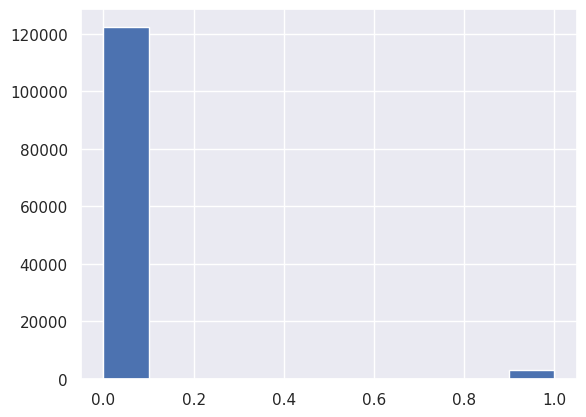

In [ ]:
df_train['isFraud'].hist()

**Вывод:** Классы сильно несбалансированы. Мошеннических транзакций значительно меньше, чем обычных транзакций

Проверю связь с целевой переменной деанонимизированных столбцов и столбцов, предназначение которых мне известно.

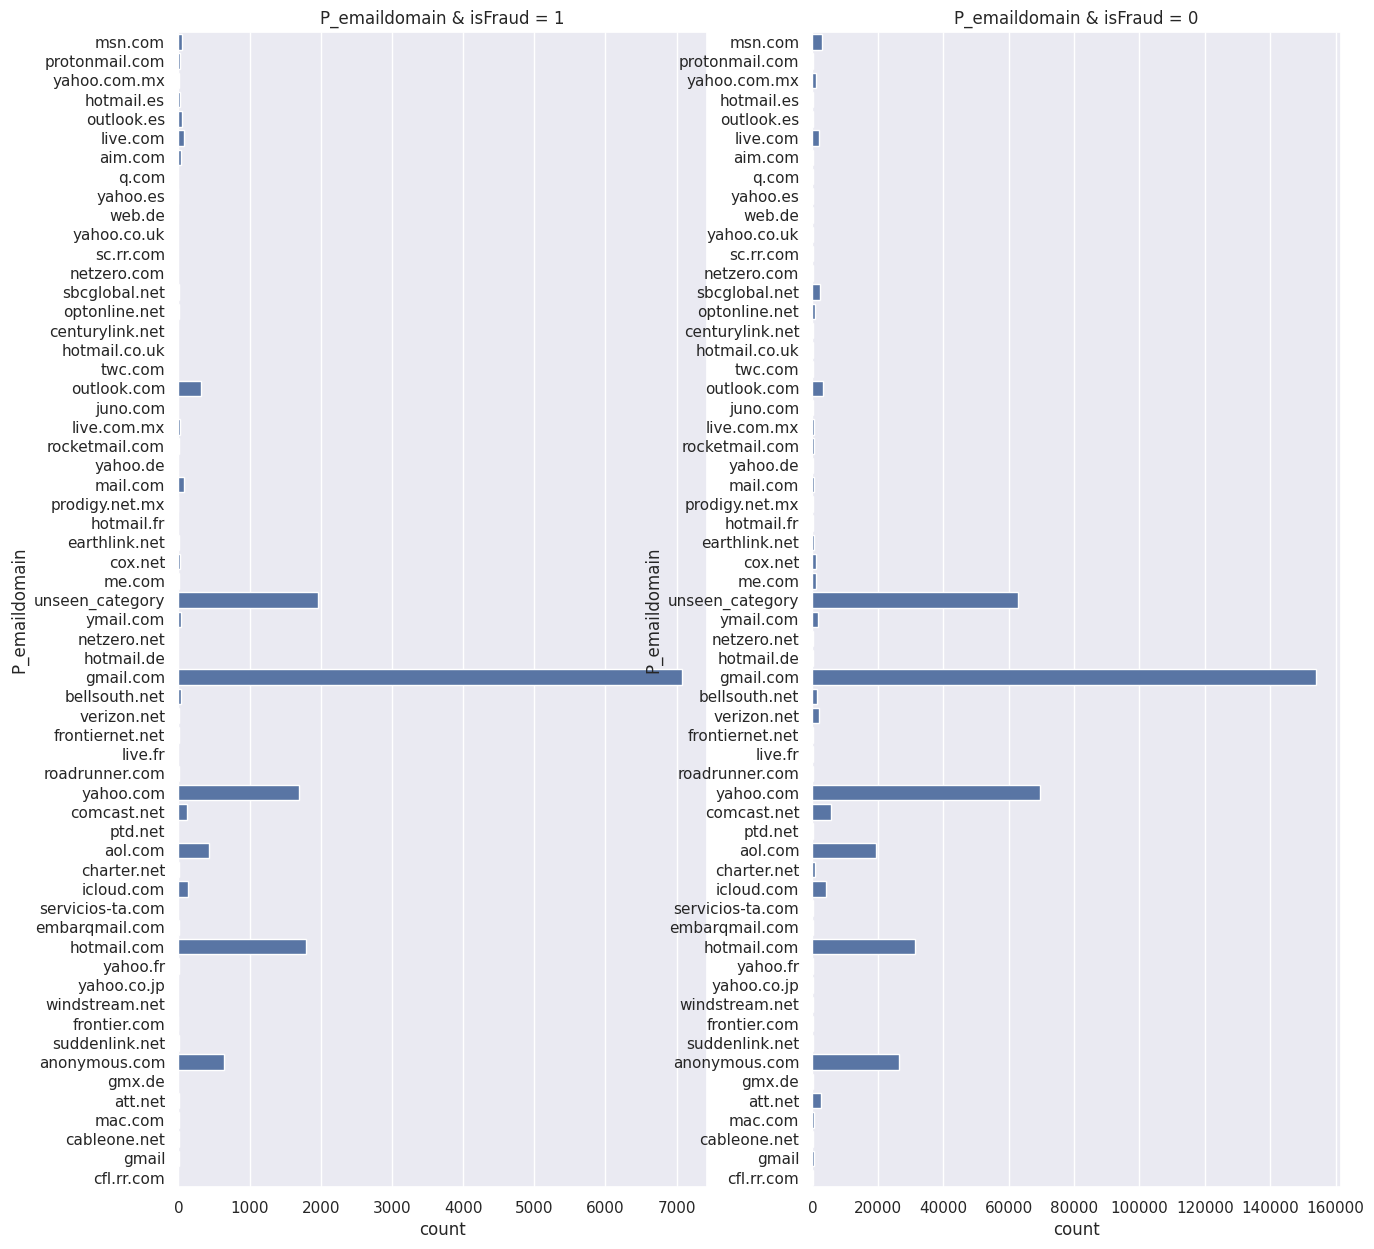

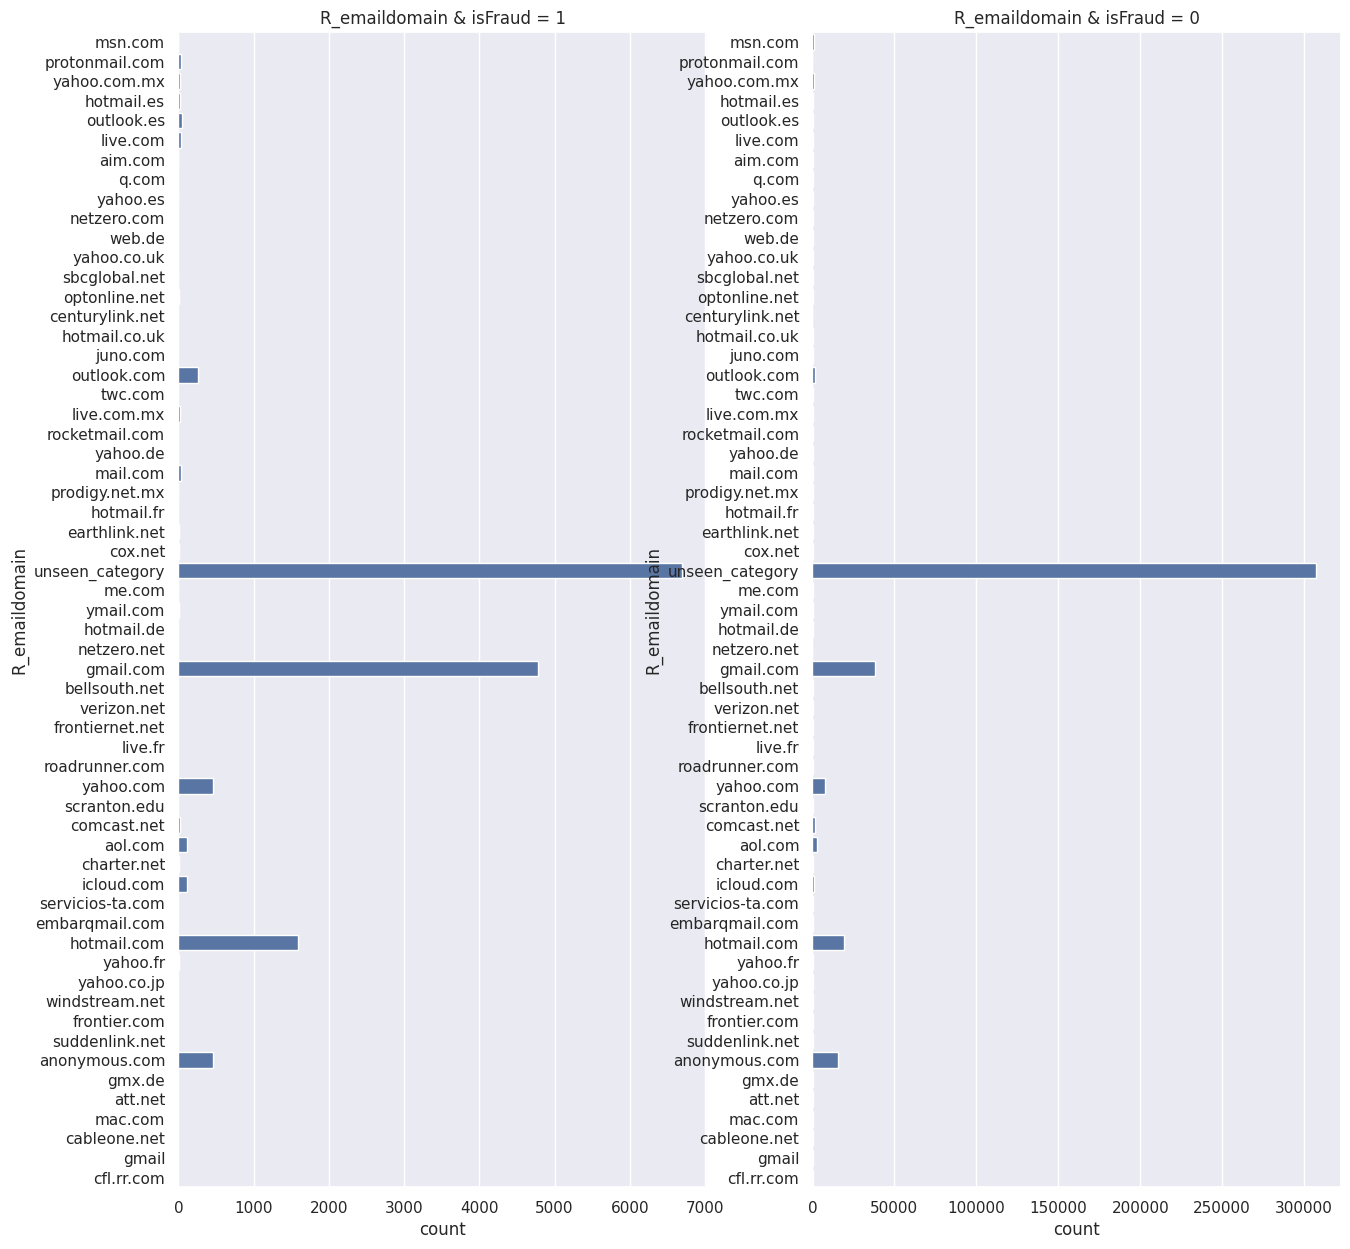

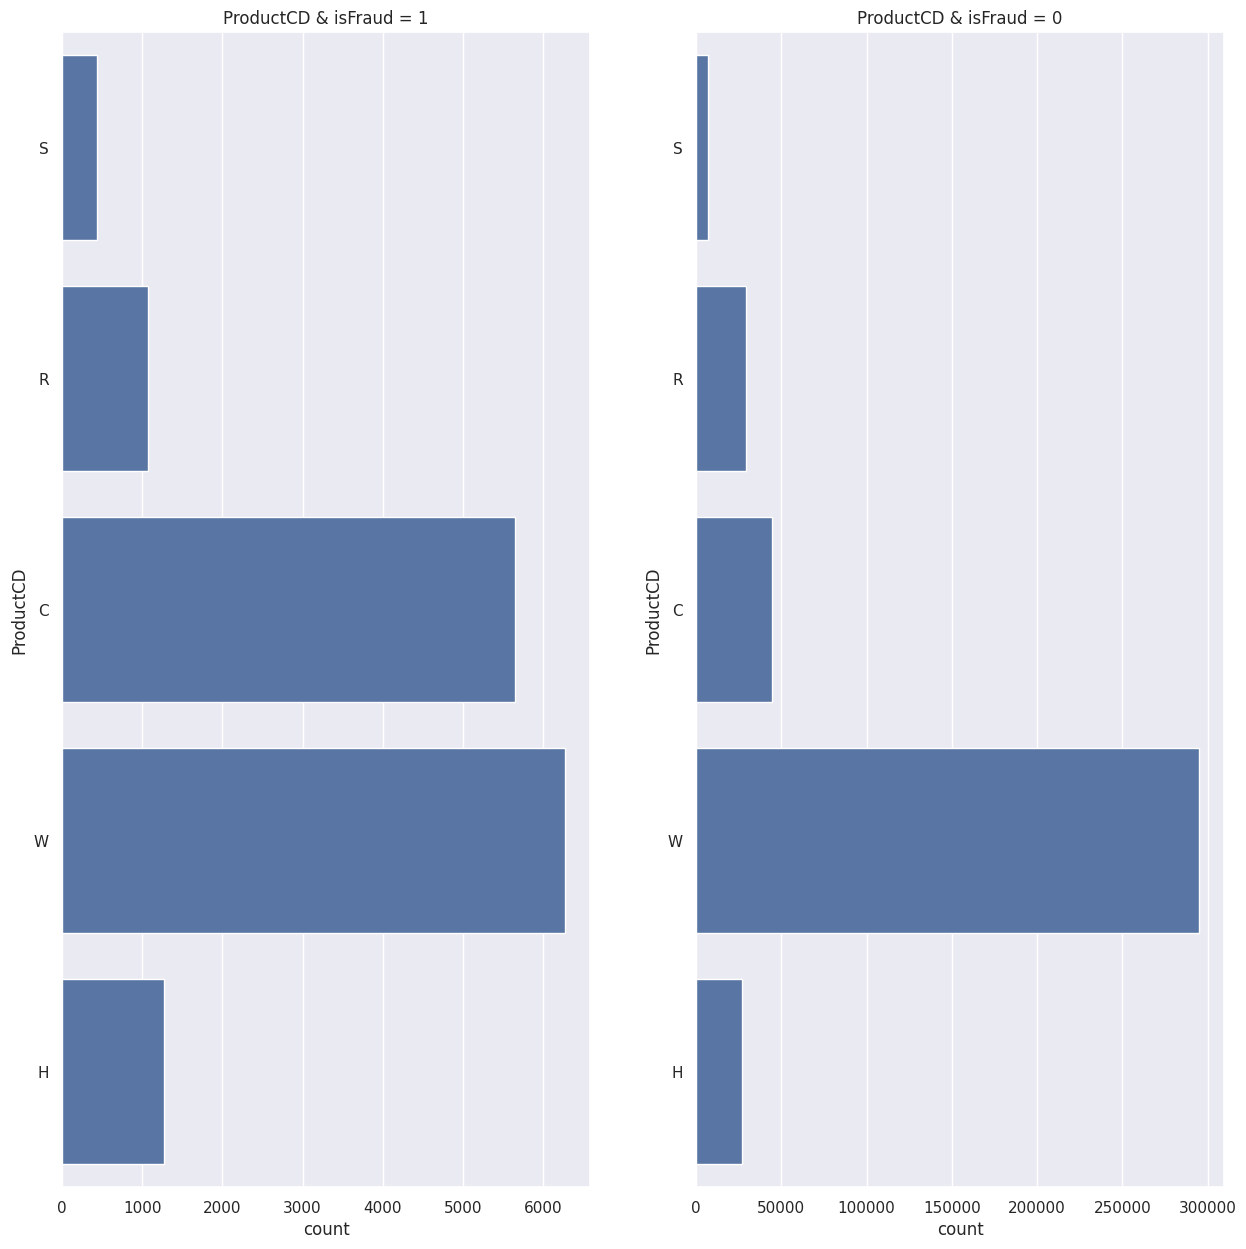

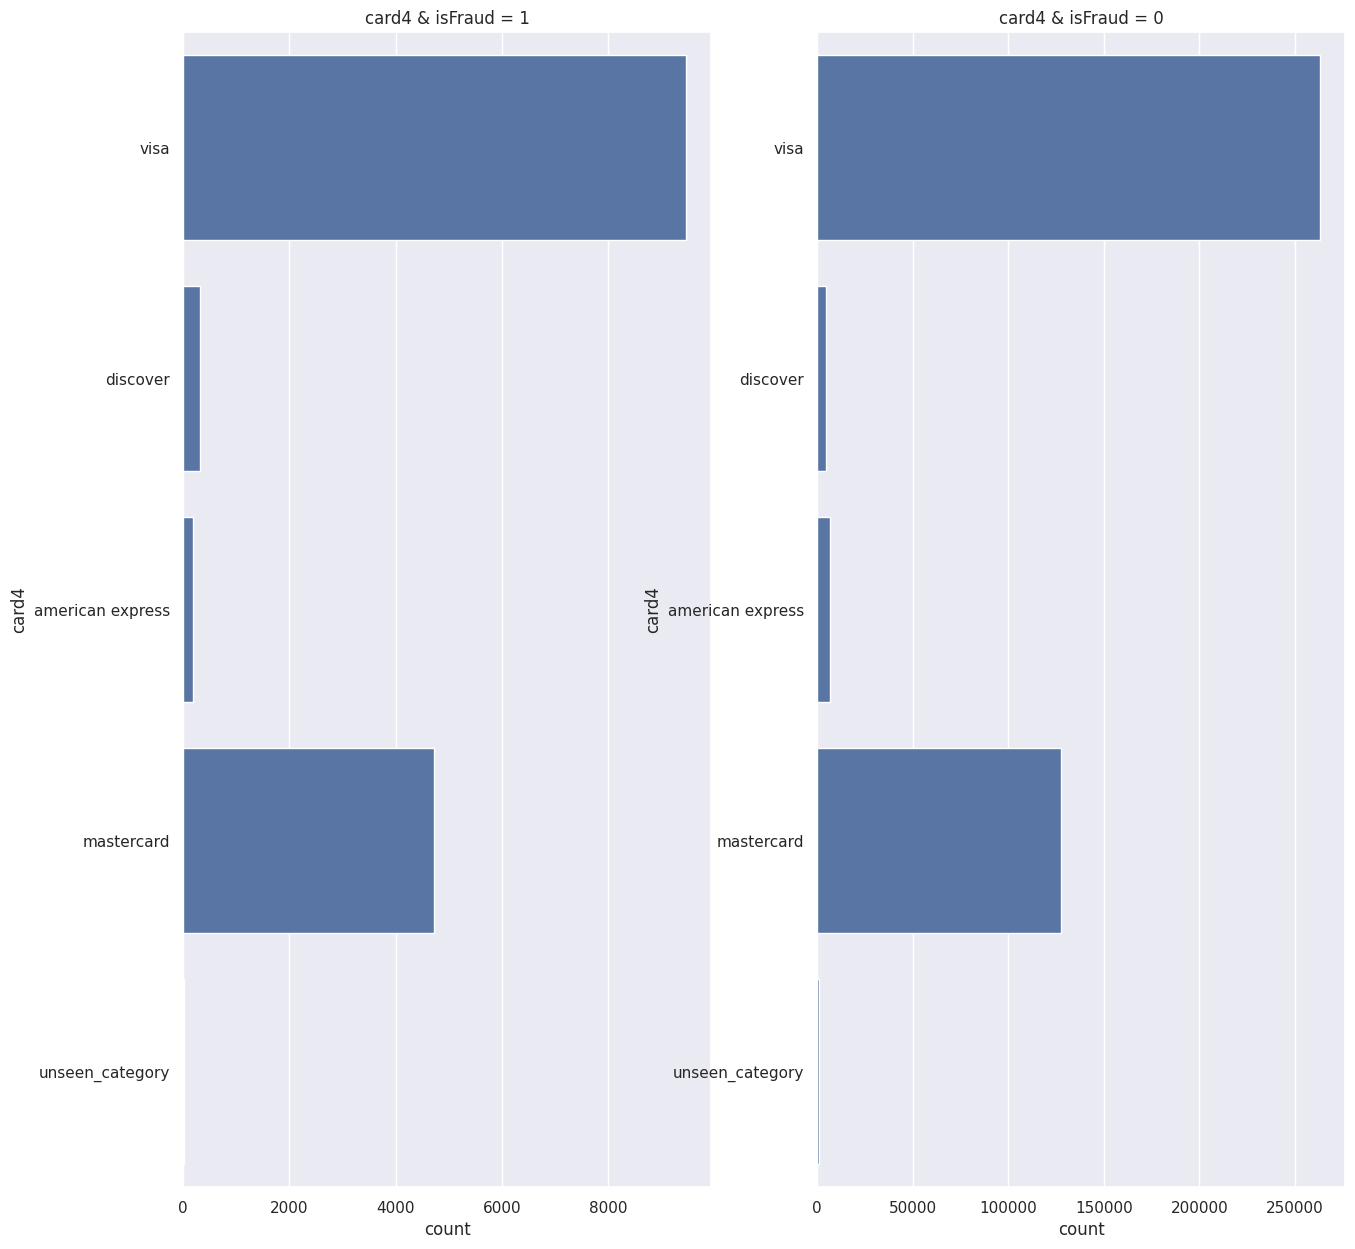

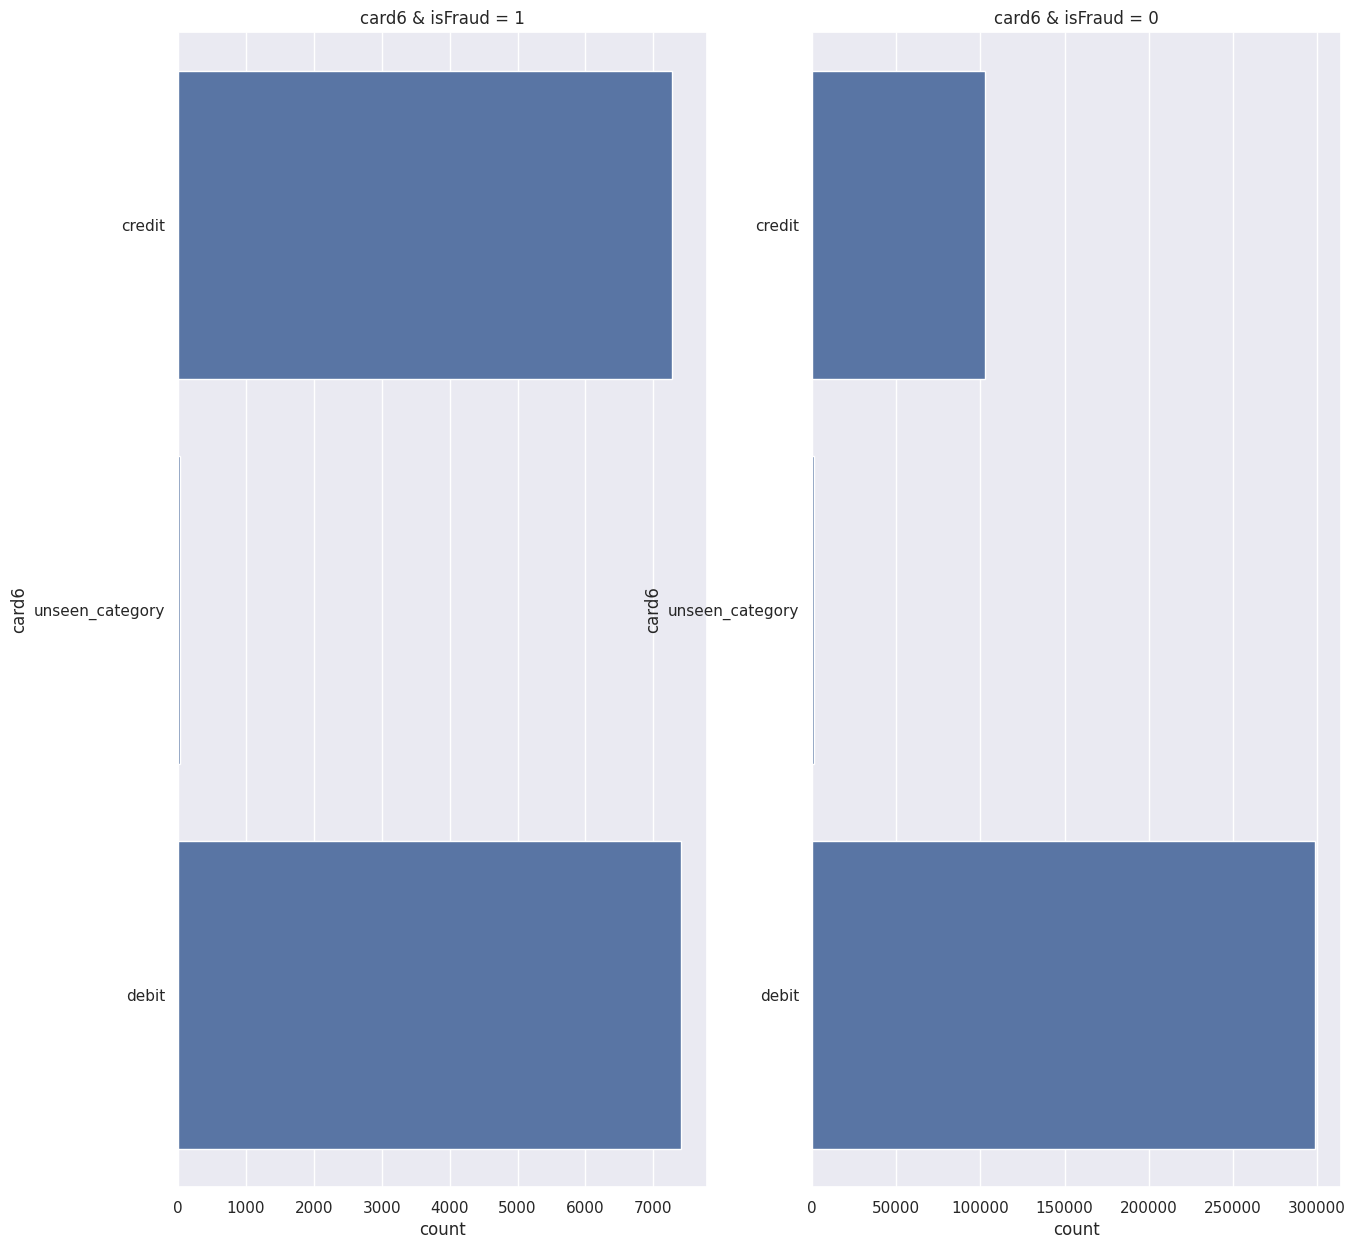

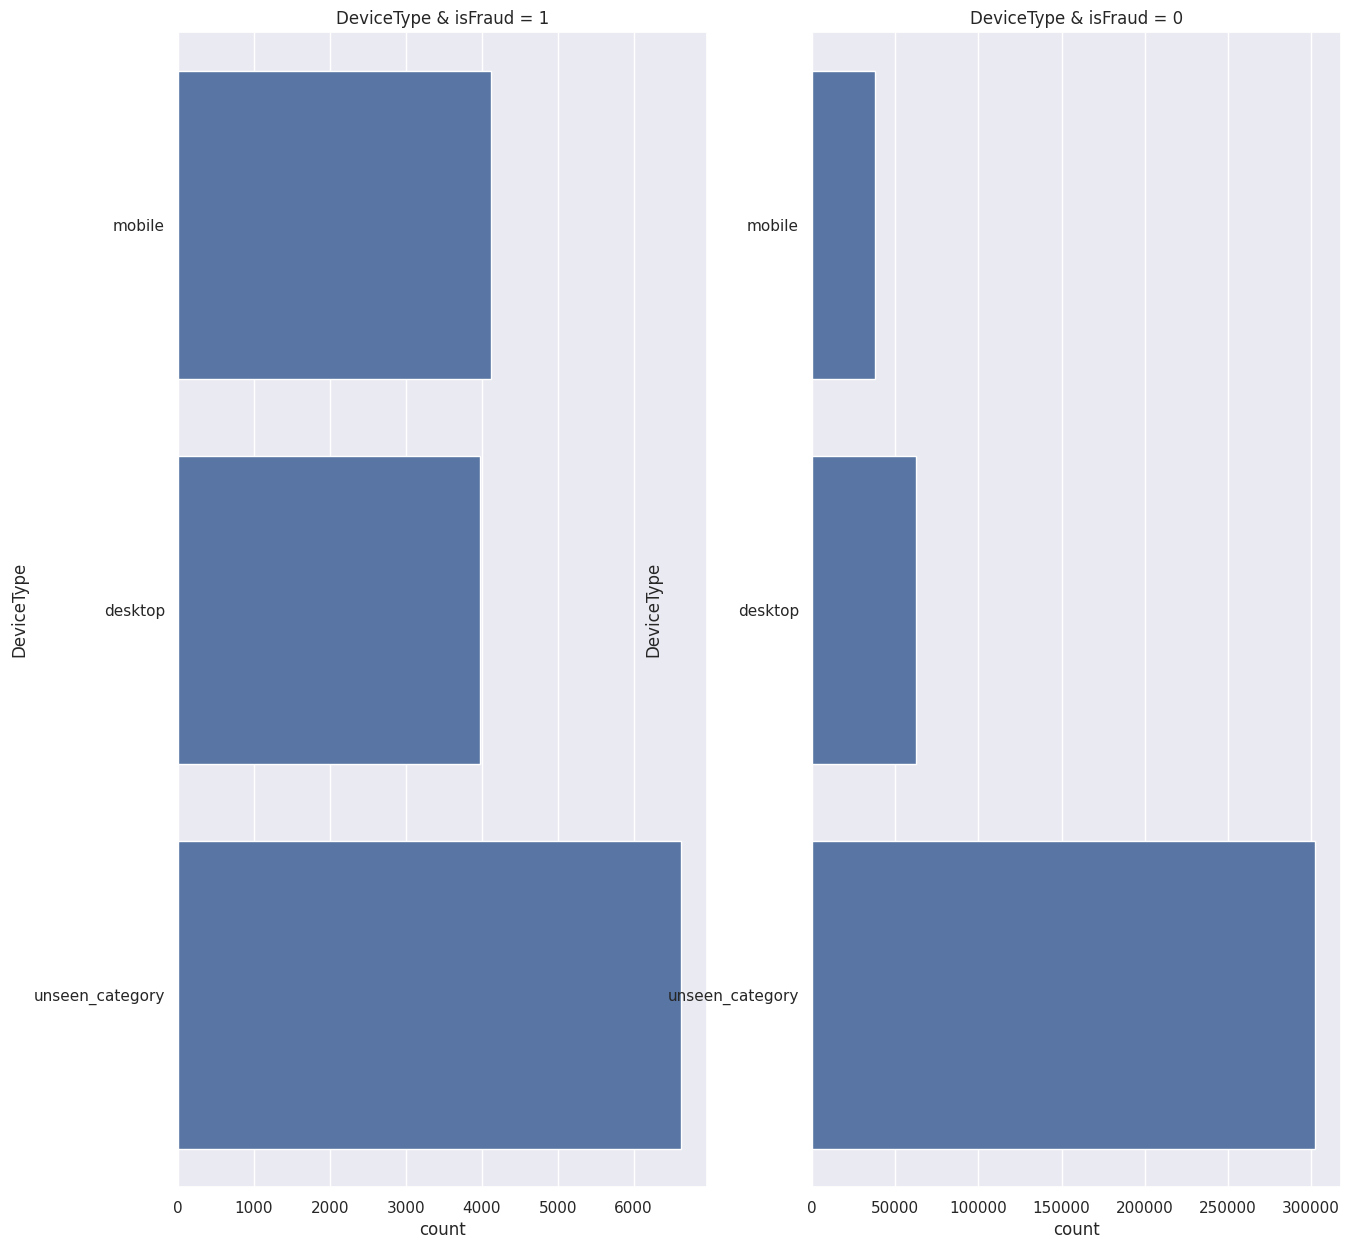

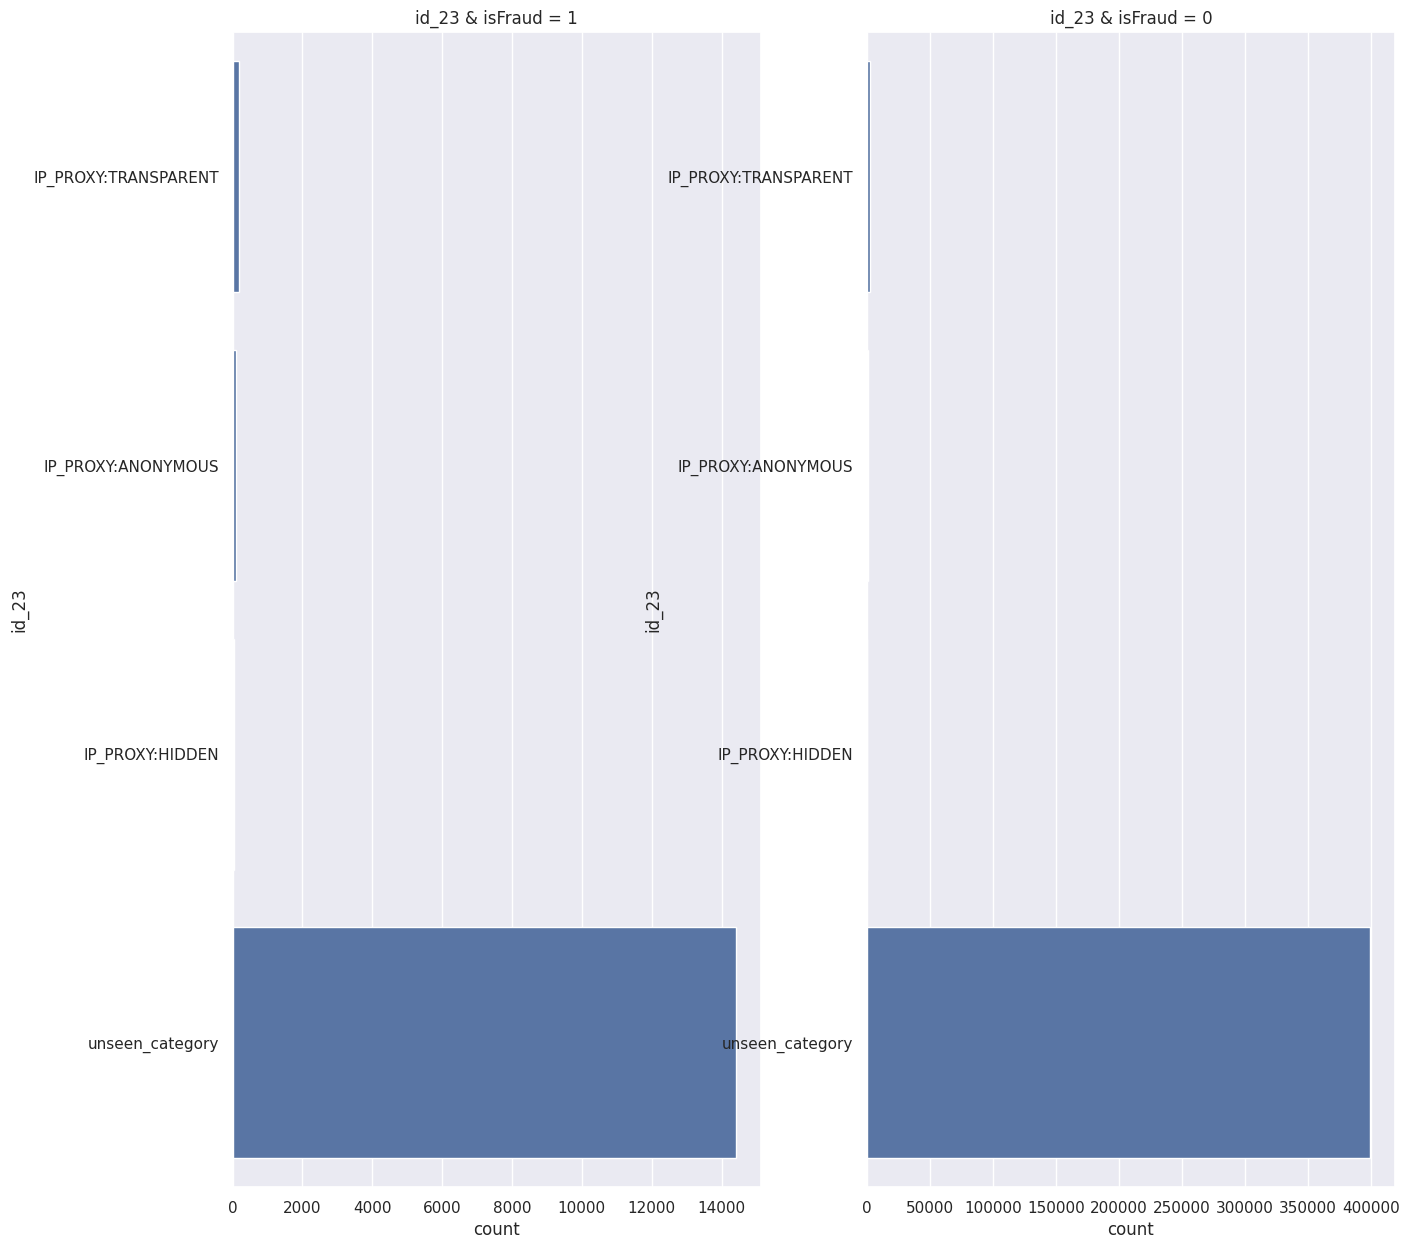

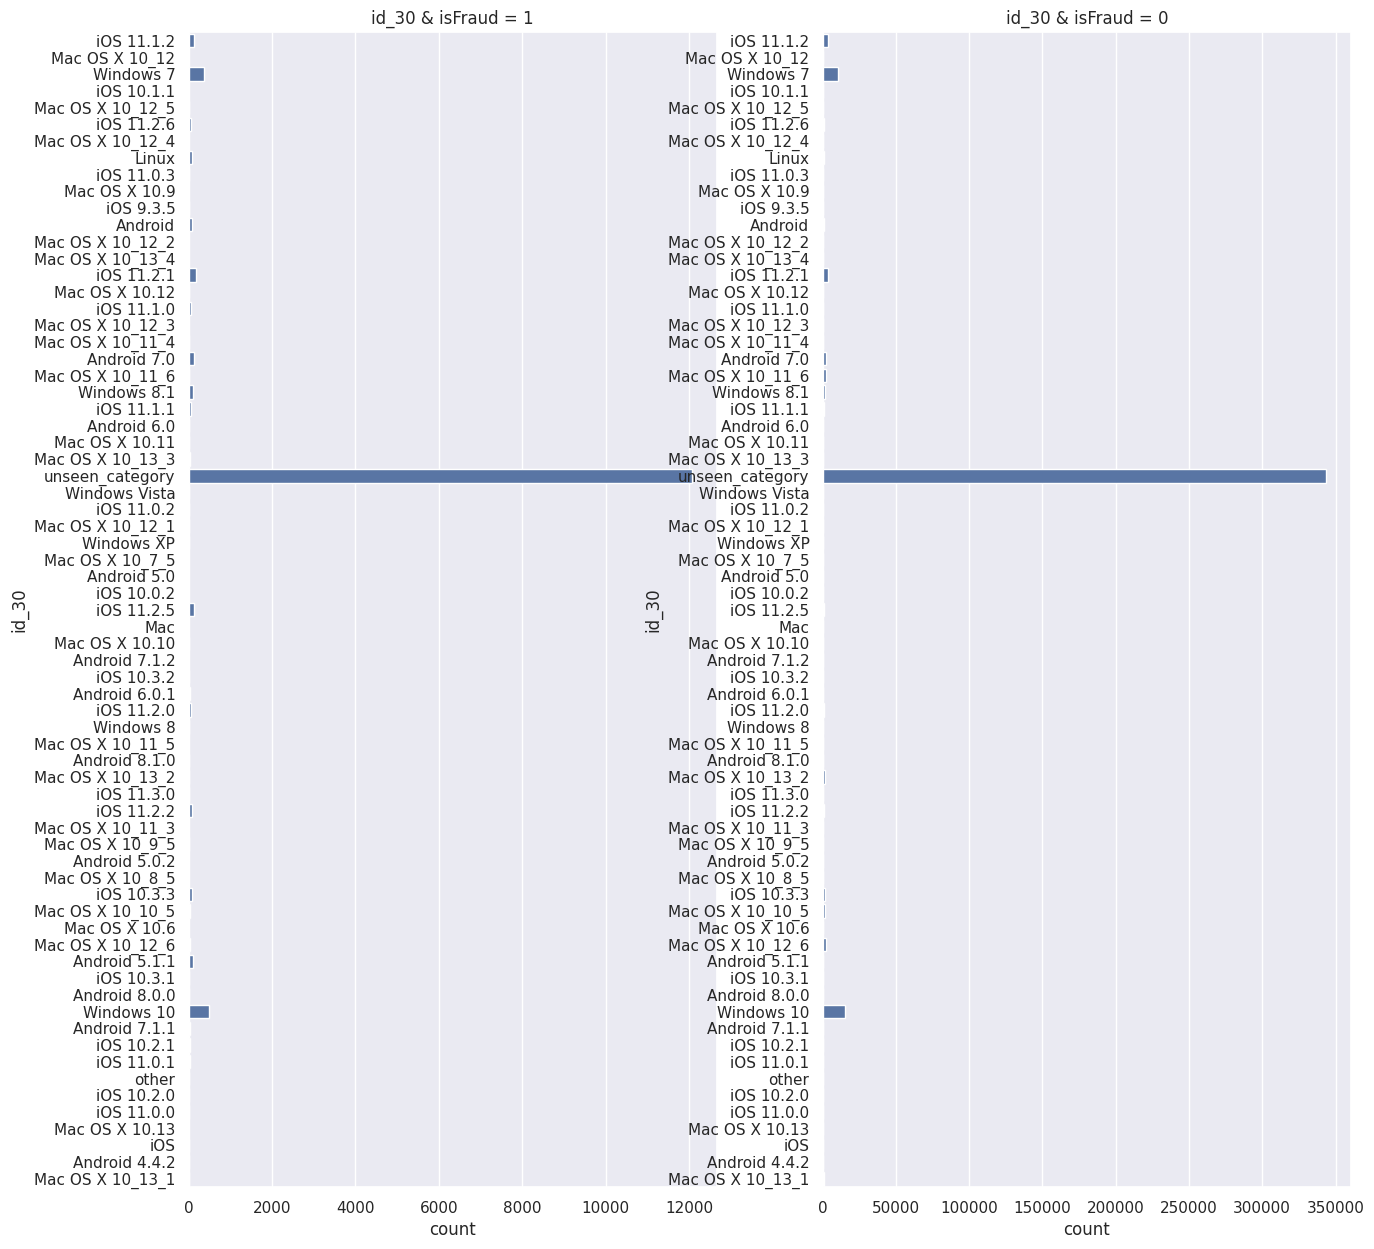

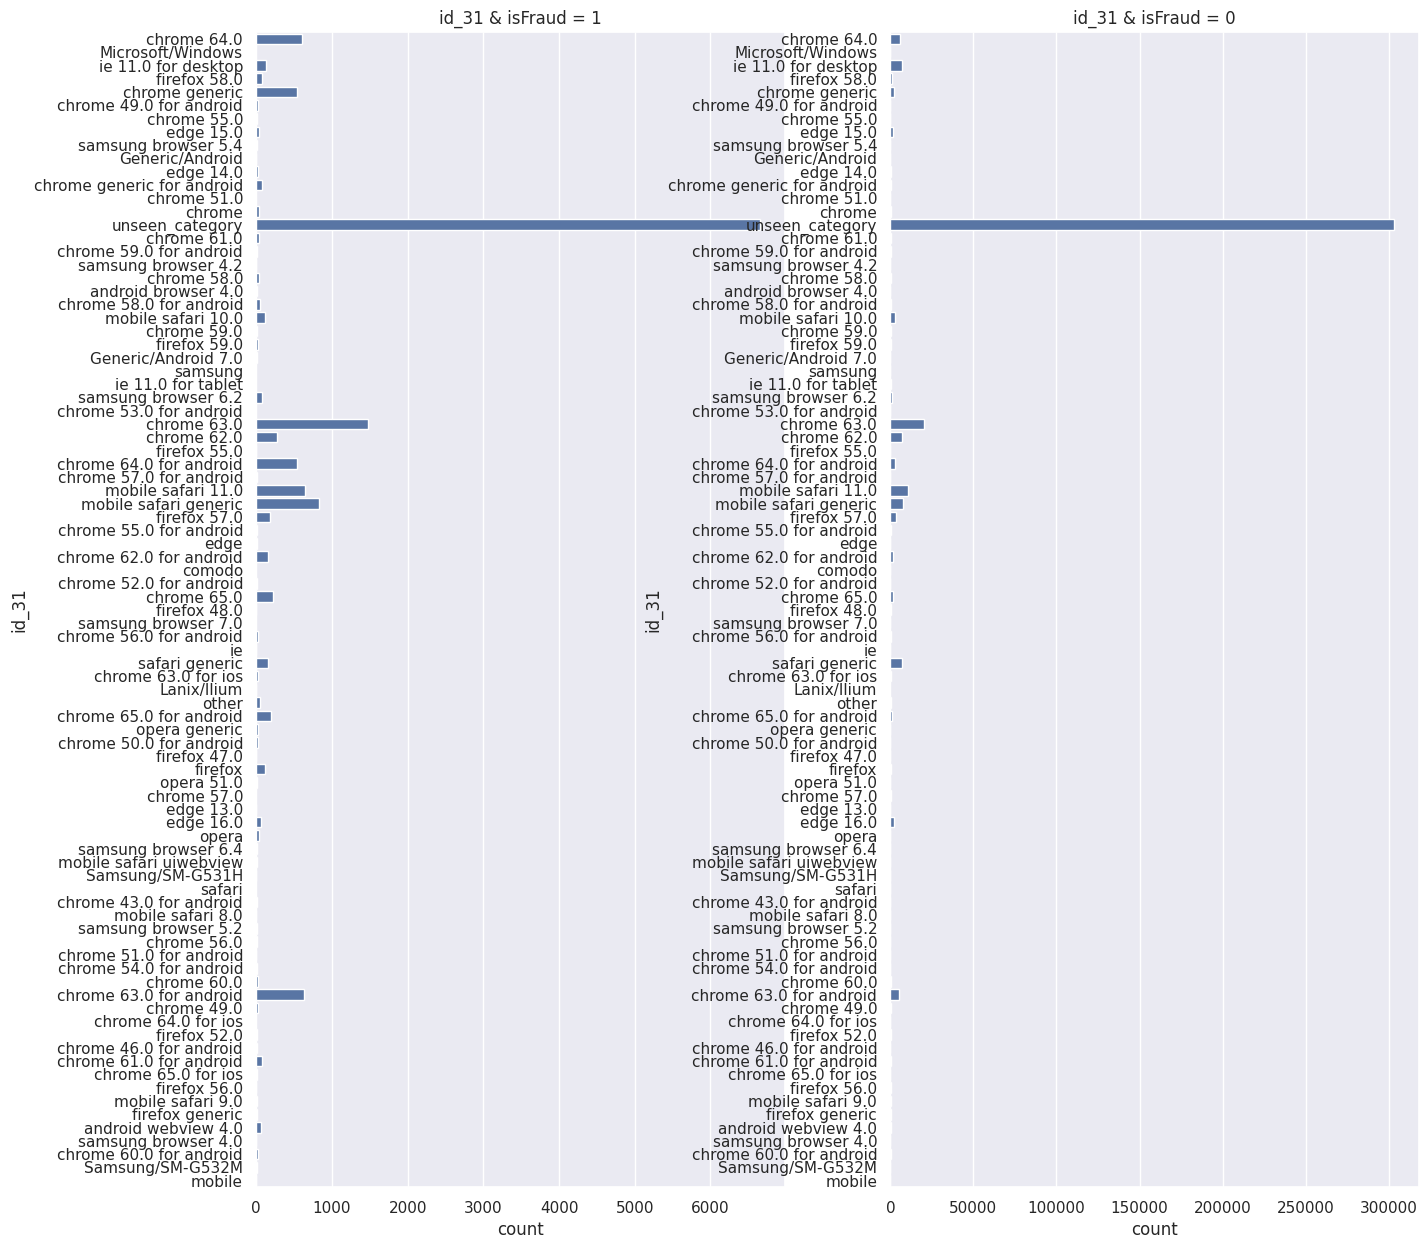

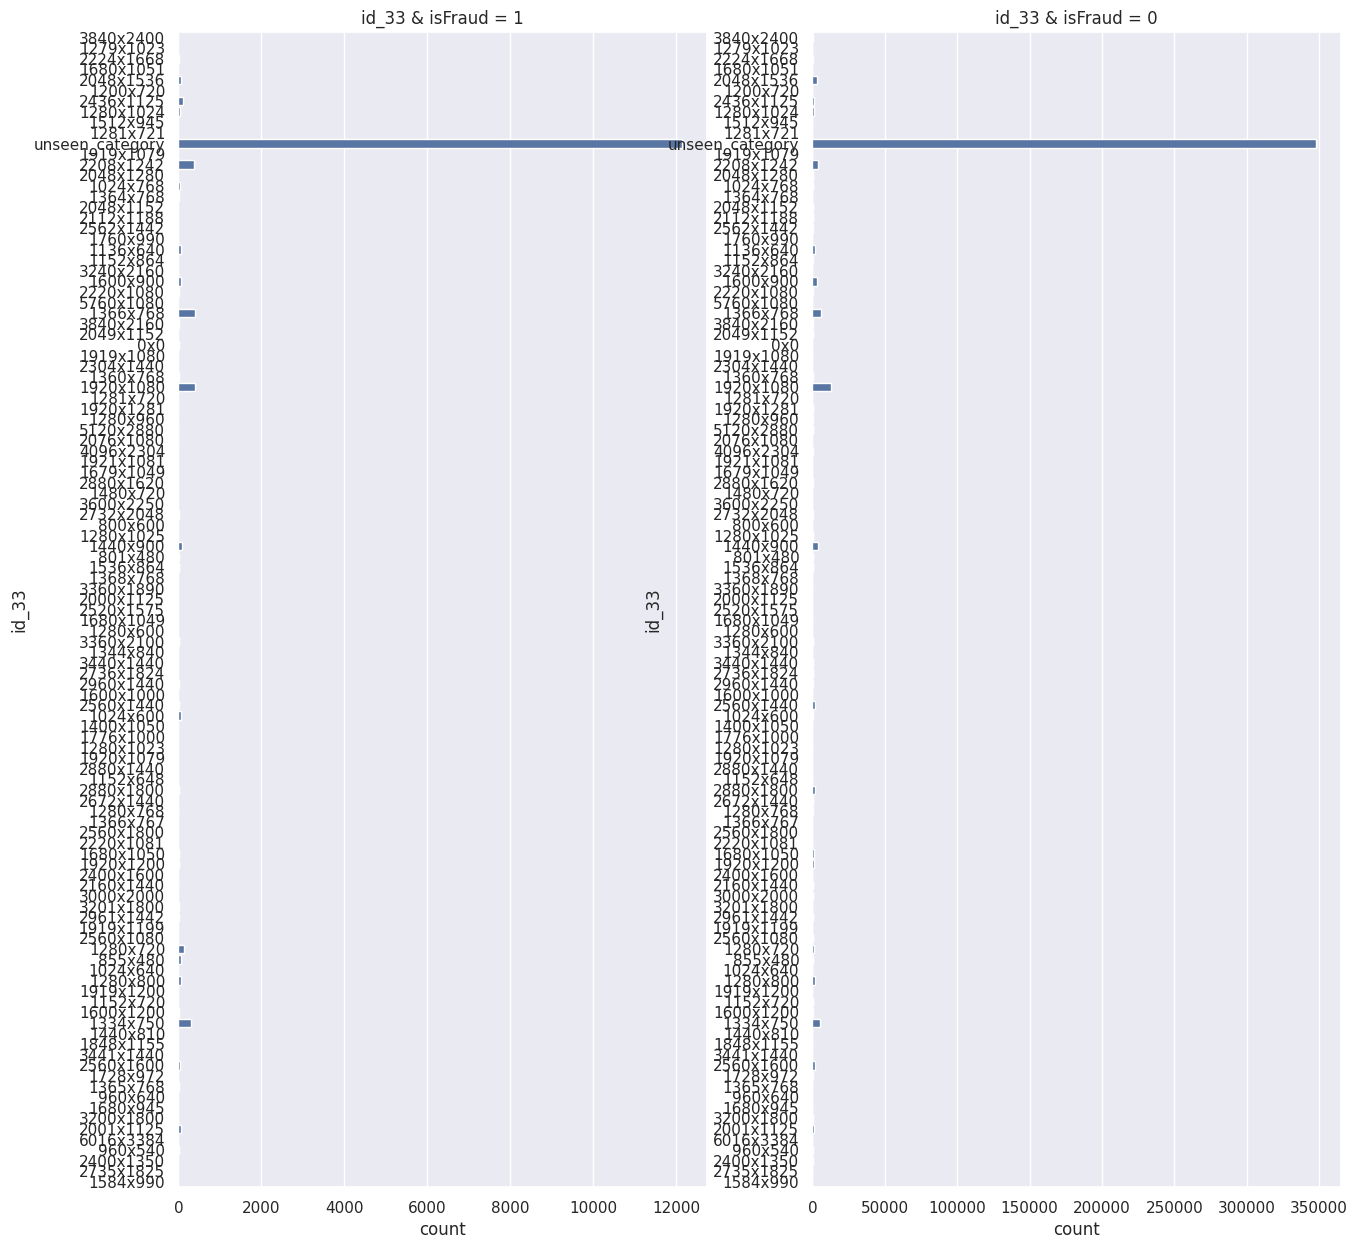

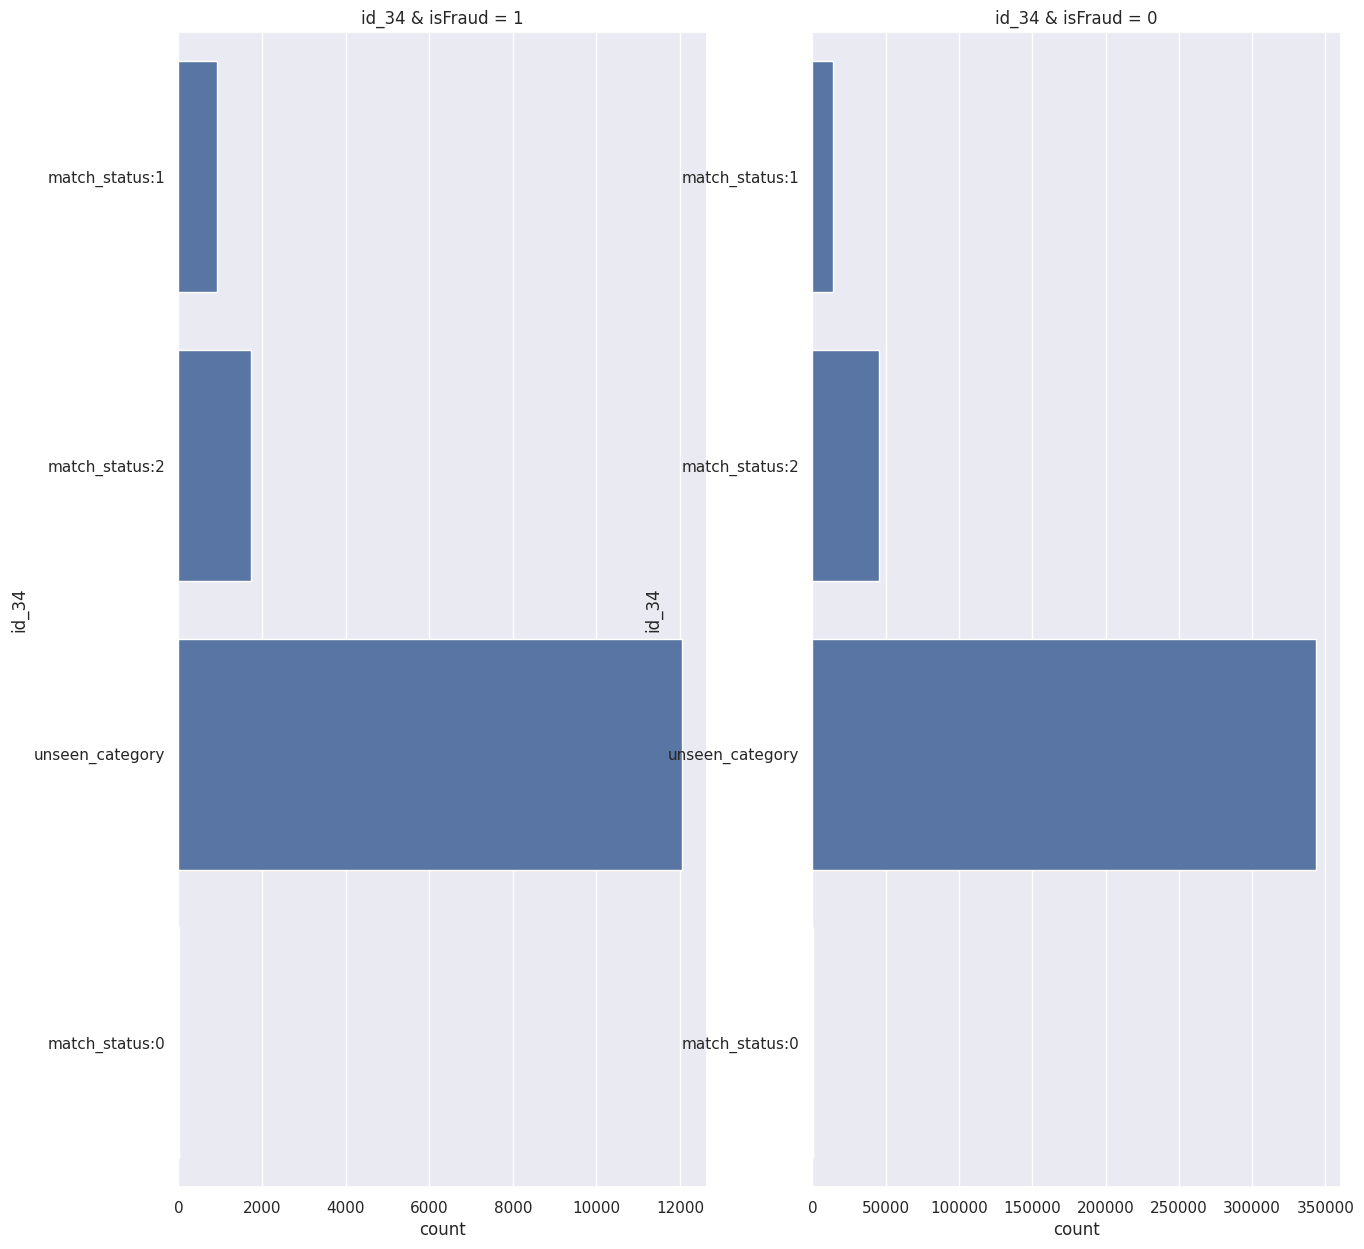

In [ ]:
cols_target = ['P_emaildomain', 'R_emaildomain', 'ProductCD', 'card4', 'card6', 'DeviceType', 'id_23', 'id_30', 'id_31', 'id_33', 'id_34']

for col in cols_target:
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 15))
    unique_values = [x for x in list(set(df_train[col].values).intersection(set(df_test[col].values))) if str(x) != 'nan']
    sns.countplot(y=col, ax=ax[0], data=df_train.loc[df_train['isFraud'] == 1], order=unique_values)
    ax[0].set_title(col + ' & isFraud = 1')
    sns.countplot(y=col, ax=ax[1], data=df_train.loc[df_train['isFraud'] == 0], order=unique_values)
    ax[1].set_title(col + ' & isFraud = 0')
    plt.show()

**Вывод:** для предсказываемого класса сильно чаще встречается категория **"C" в ProductCD**, категория **"credit" для card6**, **"mobile" для DeviceType**.

Остальные категории не сильно отличаются между классами. В рассмотренных категориях очень много пропущенных значений ("unseen_category")

Проверю распределение признаков на трейне и тесте. Признаки с небольшим количеством категорий проверю визуально, по признакам с большим количеством категорий выведу количество новых категорий в тесте текстом

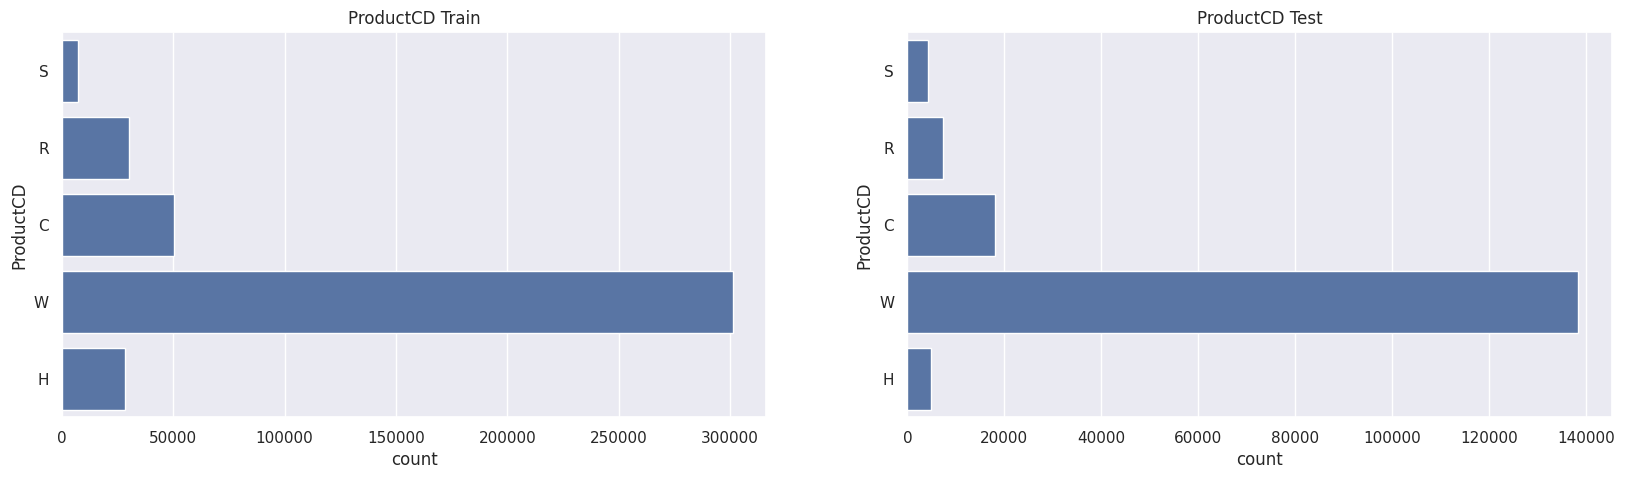

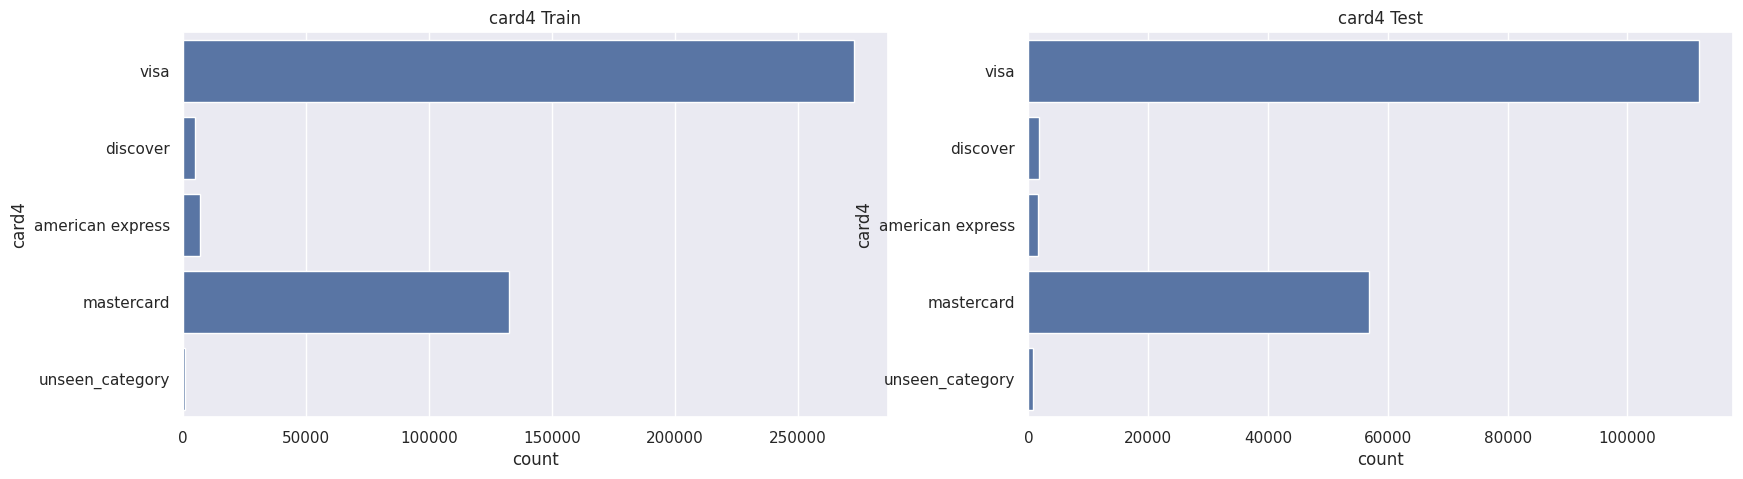

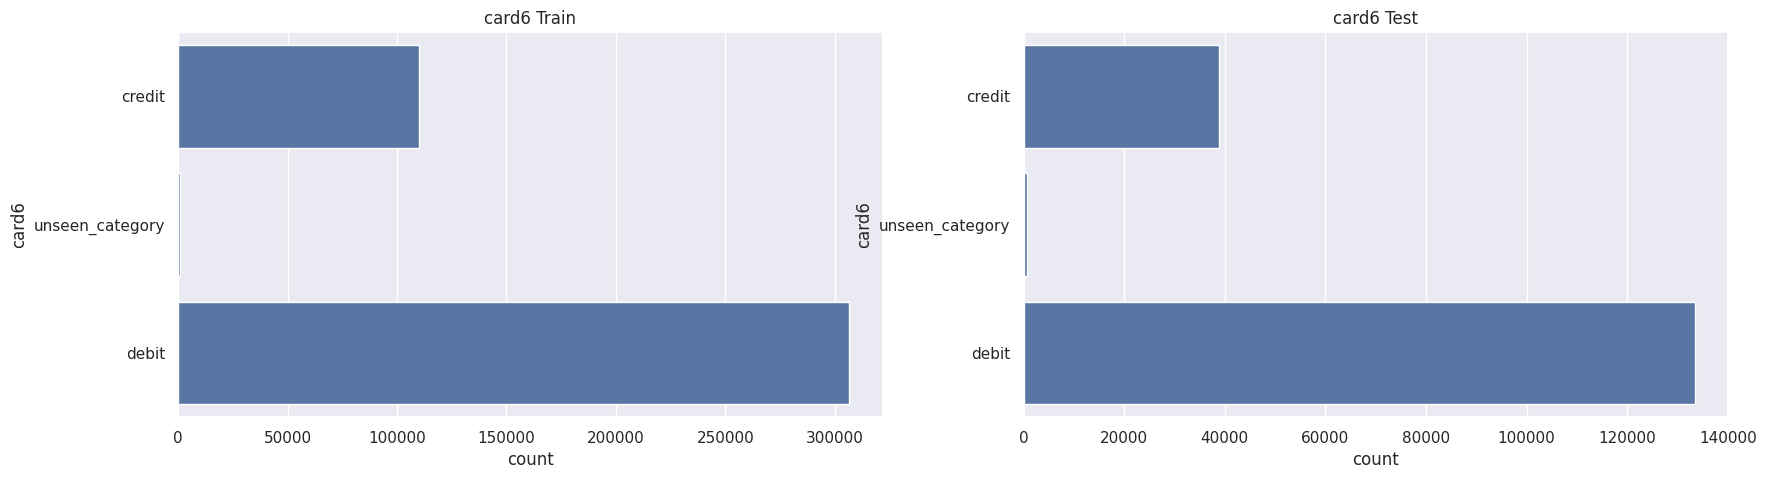

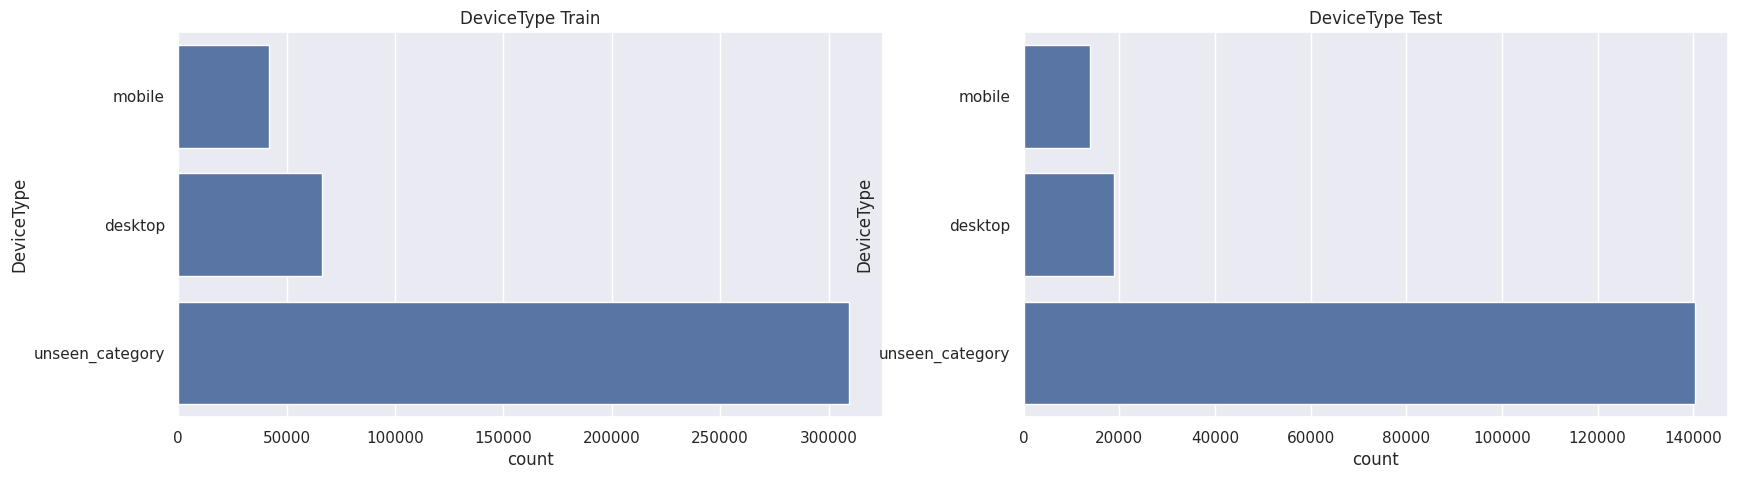

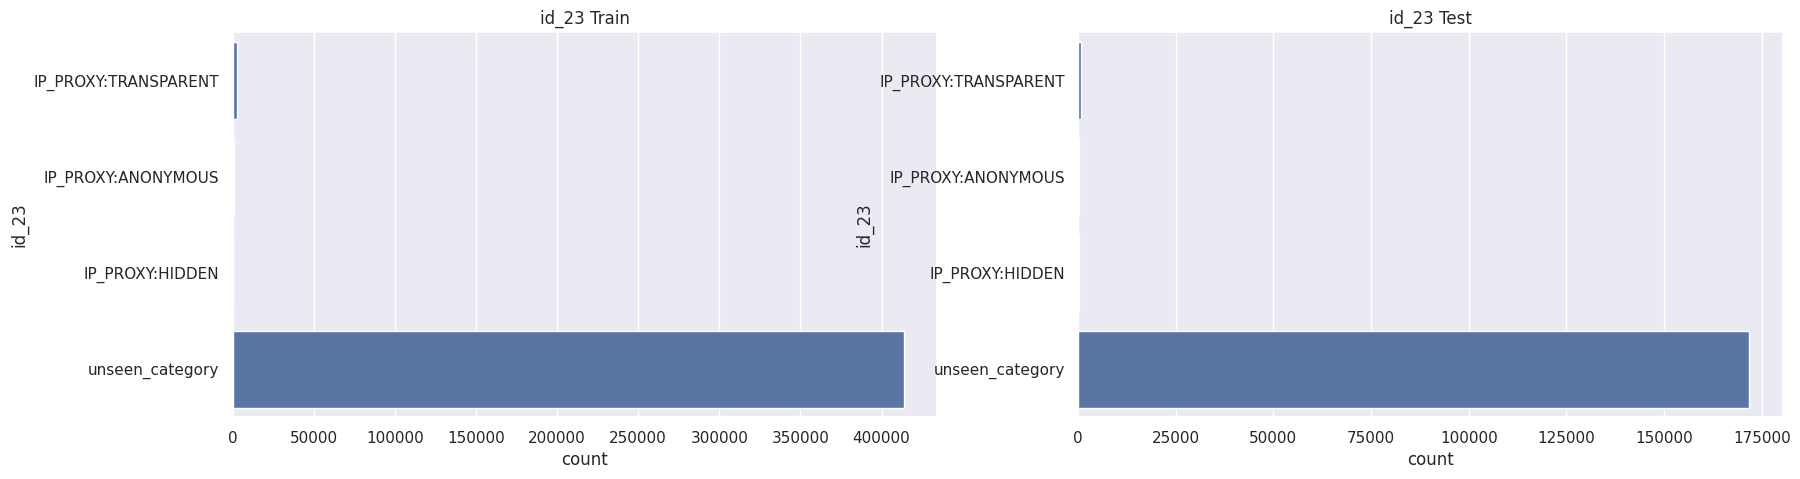

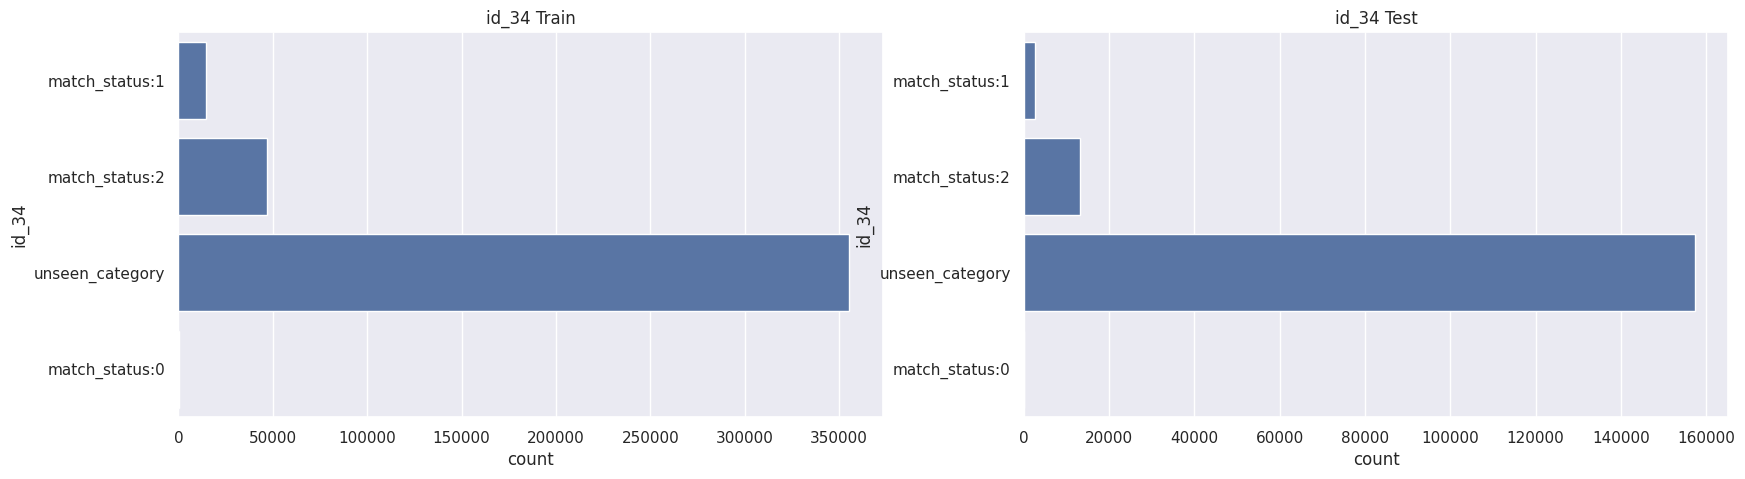

In [ ]:
cols_target = ['ProductCD', 'card4', 'card6', 'DeviceType', 'id_23', 'id_34']

for col in cols_target:
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
    unique_values = [x for x in list(set(df_train[col].values).intersection(set(df_test[col].values))) if str(x) != 'nan']
    sns.countplot(y=col, ax=ax[0], data=df_train, order=unique_values)
    ax[0].set_title(col + ' Train')
    sns.countplot(y=col, ax=ax[1], data=df_test, order=unique_values)
    ax[1].set_title(col + ' Test')
    plt.show()

In [ ]:
cols_target = ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33']

for col in cols_target:
    train_unique = df_train[col].unique()
    test_unique = df_test[col].unique()
    print(f"{col} Новых значений в тесте: {len([val for val in test_unique if val not in train_unique ])}")

P_emaildomain Новых значений в тесте: 0
R_emaildomain Новых значений в тесте: 0
id_30 Новых значений в тесте: 4
id_31 Новых значений в тесте: 20
id_33 Новых значений в тесте: 77


И проверить как распределены транзакции в трейне и тесте

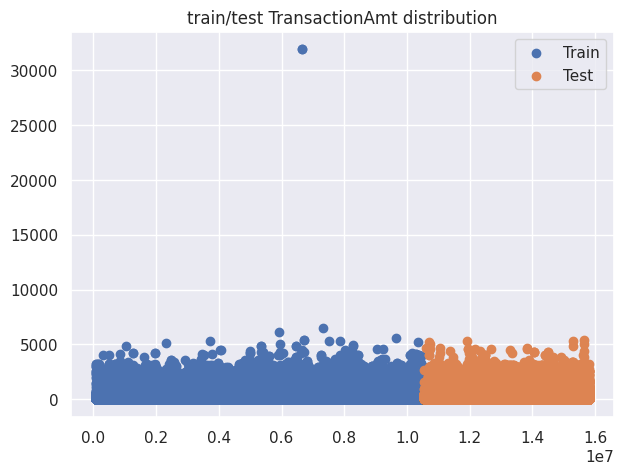

In [ ]:
plt.figure(figsize=(7, 5))
plt.title('train/test TransactionAmt distribution')
plt.scatter(df_train['TransactionDT'], df_train['TransactionAmt'], label='Train')
plt.scatter(df_test['TransactionDT'], df_test['TransactionAmt'], label='Test')
plt.legend(loc='best')
plt.show()

**Вывод:** Данные в трейне и тесте не сильно отличаются друг от друга. Для категориальных признаков в тесте встречаются новые значения, поэтому нужно аккуратно подходить к кодированию признаков.

Стоит проверить как отличаются значение в сумме транзакций по целевой переменной...

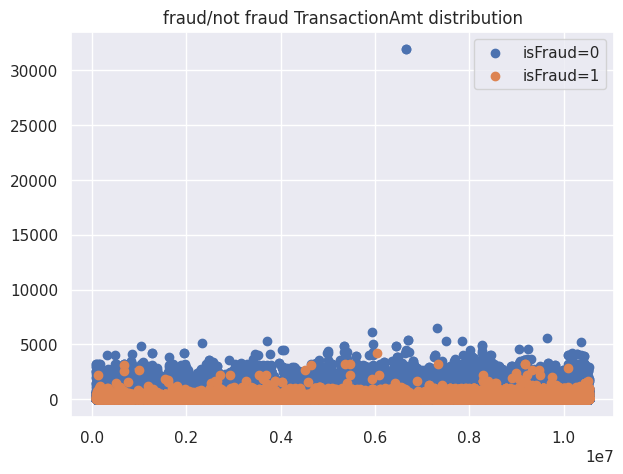

In [ ]:
plt.figure(figsize=(7, 5))
plt.title('fraud/not fraud TransactionAmt distribution')
plt.scatter(df_train[df_train['isFraud']==0]['TransactionDT'], df_train[df_train['isFraud']==0]['TransactionAmt'], label='isFraud=0')
plt.scatter(df_train[df_train['isFraud']==1]['TransactionDT'], df_train[df_train['isFraud']==1]['TransactionAmt'], label='isFraud=1')
plt.legend(loc='best')
plt.show()

Можно попробовать добавить новые признаки...

Взял идею из https://colab.research.google.com/drive/1pg1xZa8koJeUaZA35e7g1ISGqNlHDHZW#scrollTo=-SIcjRnVTkw9

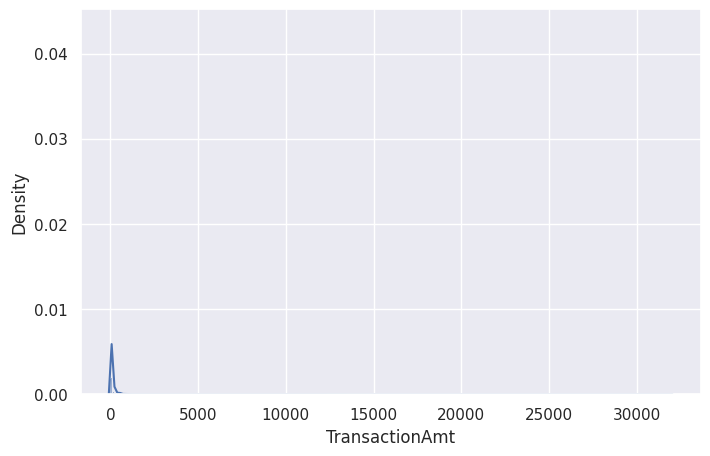

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_train['TransactionAmt'], kde=True, stat="density", kde_kws=dict(cut=5))
plt.show()

Распределение смещено влево, стоит прологарифмировать признак...

In [ ]:
train_amt_log = np.log1p(df_train['TransactionAmt'])
test_amt_log = np.log1p(df_test['TransactionAmt'])
df_train['TransactionAmt_log'] = train_amt_log
df_test['TransactionAmt_log'] = test_amt_log

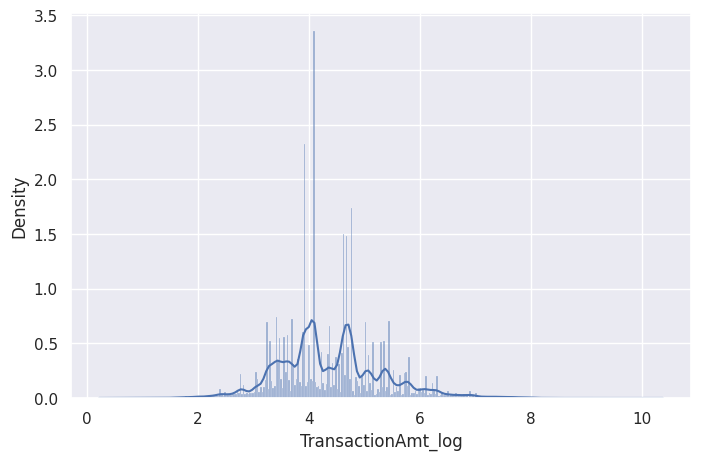

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_train['TransactionAmt_log'], kde=True, stat="density")
plt.show()

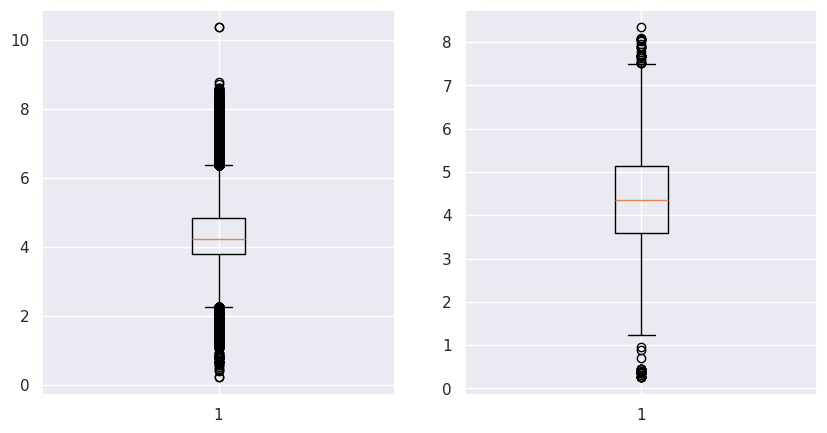

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes[0].boxplot(df_train[df_train['isFraud']==0]['TransactionAmt_log'])
axes[1].boxplot(df_train[df_train['isFraud']==1]['TransactionAmt_log'])
plt.show()

In [ ]:
df_train[df_train['isFraud']==1]['TransactionAmt'].mean(), df_train[df_train['isFraud']==0]['TransactionAmt'].mean()

(146.4808, 134.23482)

**Вывод:** По графику видно, что обычные транзакции часто встречаются с большей суммой перевода, чем мошеннические, но сумма в USD мошеннической транзакции в среднем превышает сумму обычной транзакции

Также стоит добавить новые признаки: Количество центов в транзакции и наличие центов в транзакции (после обучения модели можно будет определить, какой из этих признаков окажется важнее)

In [ ]:
train_cents = np.modf(df_train['TransactionAmt'])[0] * 100
df_train['TransactionAmt_Cents'] = train_cents

test_cents = np.modf(df_test['TransactionAmt'])[0] * 100
df_test['TransactionAmt_Cents'] = test_cents

In [ ]:
df_train['TransactionAmt_HasCents'] = df_train['TransactionAmt_Cents'].map(lambda c: 1 if c > 0 else 0)
df_test['TransactionAmt_HasCents'] = df_test['TransactionAmt_Cents'].map(lambda c: 1 if c > 0 else 0)

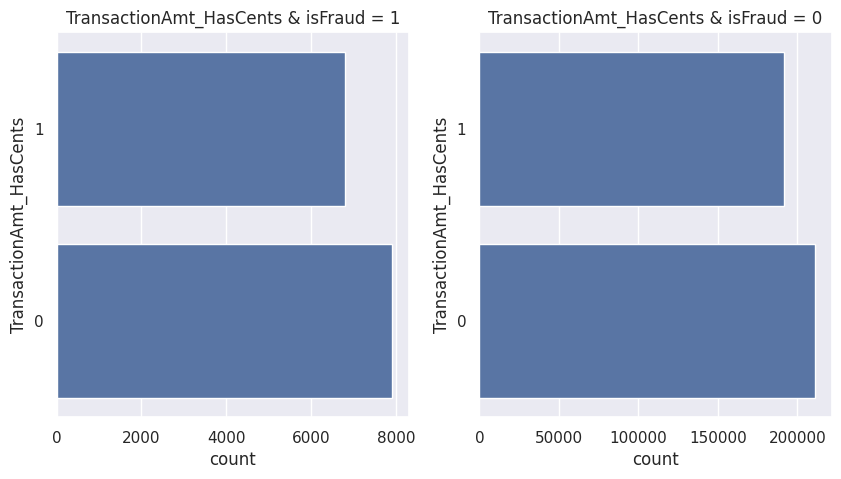

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.countplot(y='TransactionAmt_HasCents', ax=ax[0], data=df_train.loc[df_train['isFraud'] == 1], order=[1, 0])
ax[0].set_title('TransactionAmt_HasCents & isFraud = 1')
sns.countplot(y='TransactionAmt_HasCents', ax=ax[1], data=df_train.loc[df_train['isFraud'] == 0], order=[1, 0])
ax[1].set_title('TransactionAmt_HasCents & isFraud = 0')
plt.show()

Catboost умеет работать с категориальными столбцами, но стоит попробовать еще и другие модели. Поэтому сделаю копию с закодированными признаками.  
Закодирую признаки с помощью OneHotEncoding, а признаки с большим количеством категорий с помощью TargetEncoding

Чтобы не создавать лишние столбцы проверю, где в тесте все категории входят в категории трейна. Для таких категорий сделаю drop_first.  
Также есть признаки с большим количеством категорий, такие категории лучше закодировать другим способом

In [ ]:
categorical_cols = df_train.select_dtypes('object').columns

drop_first_cols=[]
full_cols=[]
target_en_cols=[]
for col in categorical_cols:
    train_unique = df_train[col].unique()
    test_unique = df_test[col].unique()
    only_test_unique = len([val for val in test_unique if val not in train_unique ])
    if (len(train_unique) + only_test_unique) > 10:
        target_en_cols.append(col)
    elif only_test_unique == 0:
        drop_first_cols.append(col)
    else:
        full_cols.append(col)

In [ ]:
df_train_enc = df_train.copy()
df_test_enc = df_test.copy()

In [ ]:
te = TargetEncoder(smoothing=1)
for col in target_en_cols:
    df_train_enc[col] = te.fit_transform(df_train_enc[col], df_train_enc['isFraud'])
    df_train_enc.drop(col, axis=1, inplace=True)
    df_test_enc[col] = te.transform(df_test_enc[col])
    df_test_enc.drop(col, axis=1, inplace=True)

In [ ]:
ohe_drop_first = OneHotEncoder(drop='first', sparse_output=False)
ohe_drop_first.set_output(transform = "pandas")
for col in drop_first_cols:
    df_train_enc = pd.concat([df_train_enc, ohe_drop_first.fit_transform(df_train_enc[[col]])], axis=1)
    df_train_enc.drop(col, axis=1, inplace=True)
    df_test_enc = pd.concat([df_test_enc, ohe_drop_first.transform(df_test_enc[[col]])], axis=1)
    df_test_enc.drop(col, axis=1, inplace=True)

In [ ]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.set_output(transform = "pandas")
for col in full_cols:
    df_train_enc = pd.concat([df_train_enc, ohe.fit_transform(df_train_enc[[col]])], axis=1)
    df_train_enc.drop(col, axis=1, inplace=True)
    df_test_enc = pd.concat([df_test_enc, ohe.transform(df_test_enc[[col]])], axis=1)
    df_test_enc.drop(col, axis=1, inplace=True)

In [ ]:
df_train_enc.shape, df_test_enc.shape

((417559, 467), (172981, 466))

In [ ]:
df_train.shape, df_test.shape

((417559, 437), (172981, 436))

# **Задание 2 (3 балла)**

Обучите несколько ML-моделей для решения поставленной задачи.
Оцените их качество двумя способами:

1) на кросс-валидации

2) на лидерборде

Подберите число фолдов на кросс-валидации так, чтобы метрики, которые вы видите, были максимально близки на кросс-валидации и на лидерборде.

По результатам экспериментов постройте таблицу:
* в каждой строке таблицы - результаты одной модели
* по столбцам: качество на кросс-валидации, качество на лидерборде, модель с гиперпараметрами
Полученную таблицу вставьте картинкой прямо в ноутбук после ячеек с кодом. Сделайте текстовые выводы.

In [ ]:
X_train = df_train.drop('isFraud', axis=1)
X_train_enc = df_train_enc.drop('isFraud', axis=1)
y_train = df_train['isFraud']

In [ ]:
del df_train

Сперва попробую обучить Catboost с указанием категориальных признаков (без кодированых признаков)

In [ ]:
categorical_features=[
    *[f'card{i}' for i in range(1, 7)], *[f'M{i}' for i in range(1, 10)],
    'ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
    'DeviceType', 'DeviceInfo', *[f'id_{i}' for i in range(12, 39)],
    'TransactionAmt_HasCents'
]
catboost = CatBoostClassifier(cat_features=categorical_features, random_state=42, iterations=10, verbose=False)

In [ ]:
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
# Проверял также на 6 и 9 фолдах, результаты оказывались примерно одинаковыми
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

params={
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.3, None],
    'depth': [4, 6, 10, 15, None],
    'l2_leaf_reg': [1, 3, 5, 7, 9, None]
}
catboost_rs = RandomizedSearchCV(catboost, params, n_iter=10, scoring=scorer, cv=cv, random_state=42)

In [ ]:
catboost_rs.fit(X_train, y_train)
catboost_rs.best_params_, catboost_rs.best_score_

({'learning_rate': 0.3, 'l2_leaf_reg': 3, 'depth': 15}, 0.9109844484639794)

In [ ]:
predictions = catboost_rs.predict(df_test)

In [ ]:
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_cb.csv', index=False)

**На кросс-валидации - 0.9109844484639794**  
**На лидерборде - 0.64298**  
Catboost показал отличный результат на кросс-валидации и средний результат на лидерборде. Скорее всего, модель переобучилась.

Попробую обучить LightGBM с закодированными ранее признаками и с признаками, закодированными с помощью LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train_label_enc = X_train.copy()
X_test_label_enc = df_test

obj_cols = X_train.select_dtypes('object').columns
for col in obj_cols:
    le = LabelEncoder()
    le.fit(list(df_train[col]) + list(df_test[col]))
    X_train_label_enc[col] = le.transform(df_train[col])
    X_test_label_enc[col] = le.transform(df_test[col])

In [ ]:
lgbm = LGBMClassifier(random_state=42, objective='binary', force_row_wise=True)

In [ ]:
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

params={
    'learning_rate': [0.03, 0.05, 0.1, 0.3],
    'reg_alpha': [0, 0.5, 1, 3, 5],
    'max_depth': [-1, 10, 15],
    'min_child_samples': [10, 20, 90, 120],
    'num_leaves': [10, 31, 100, 150],
    'n_estimators': [10, 30, 100]
}
lgbm_rs = RandomizedSearchCV(lgbm, params, n_iter=10, scoring=scorer, cv=cv, random_state=42)

In [ ]:
lgbm_rs.fit(X_train_label_enc, y_train)

In [ ]:
lgbm_rs.best_params_, lgbm_rs.best_score_

({'reg_alpha': 1,
  'num_leaves': 100,
  'n_estimators': 100,
  'min_child_samples': 90,
  'max_depth': -1,
  'learning_rate': 0.3},
 0.9562663354521547)

**На кросс-валидации** модель показала отличный результат судя по метрике - **0.9562663354521547**.  
**На лидерборде** удалось получить **0.64298**. Результат на лидерборде значительно ниже, чем на кросс-валидации. Подобрать количество фолдов, чтобы изменить ситуацию не удалось.  
*Вероятно, модель переобученна*, к примеру, максимальная глубина бустинга не ограничена (max_depth = -1).

In [ ]:
predictions = lgbm_rs.predict(X_test_label_enc)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_lgbm.csv', index=False)

Теперь проверю lgbm на ранее закодированных признаках

In [ ]:
X_train_enc = X_train_enc.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
df_test_enc = df_test_enc.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

In [ ]:
lgbm_rs.fit(X_train_enc, y_train)

In [ ]:
lgbm_rs.best_params_, lgbm_rs.best_score_

({'reg_alpha': 1,
  'num_leaves': 100,
  'n_estimators': 100,
  'min_child_samples': 90,
  'max_depth': -1,
  'learning_rate': 0.3},
 0.9551642984098311)

In [ ]:
predictions = lgbm_rs.predict(df_test_enc)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_lgbm_enc.csv', index=False)

**На кросс-валидации** метрика roc-auc - **0.9551642984098311**  
**На лидерборде - 0.68221**  
Результат немного усреднился.

Попробую еще раз обучить LightGBM, но на этот раз ограничу максимальную глубину деревьев и попробую уменьшить количество признаков с помощью PCA. Возможно, это улучшит результаты и сделает метрики на кросс-валидации и лидерборде ближе друг к другу.

In [ ]:
lgbm_pca = Pipeline(steps=[
    ('pca', PCA(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, objective='binary', force_row_wise=True))
])

In [ ]:
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

params={
    'pca__n_components': [0.7, 0.8, 0.9],
    'lgbm__learning_rate': [0.1, 0.3],
    'lgbm__reg_alpha': [0.5, 1, 3, 5],
    'lgbm__max_depth': [5, 10, 15, 25],
    'lgbm__min_child_samples': [10, 20, 90, 120, 150],
    'lgbm__num_leaves': [10, 31, 100, 150],
    'lgbm__n_estimators': [10, 20, 40]
}
pca_lgbm_rs = RandomizedSearchCV(lgbm_pca, params, n_iter=10, scoring=scorer, cv=cv, random_state=42)

In [ ]:
pca_lgbm_rs.fit(X_train_enc, y_train)

In [ ]:
pca_lgbm_rs.best_params_, pca_lgbm_rs.best_score_

({'pca__n_components': 0.7,
  'lgbm__reg_alpha': 3,
  'lgbm__num_leaves': 150,
  'lgbm__n_estimators': 10,
  'lgbm__min_child_samples': 20,
  'lgbm__max_depth': 25,
  'lgbm__learning_rate': 0.3},
 0.5911279925070272)

In [ ]:
predictions = pca_lgbm_rs.predict(df_test_enc)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_PCA_lgbm_enc.csv', index=False)

Для данной модели метрика на **кросс-валидации - 0.59113**  
**На лидерборде - 0.50000**  
Метрики ухудшились, но значения стали ближе друг к другу.

**Вывод:** модели сильно переобучаются и выдают средний результат на тестовых данных.

Попробую **модель логистической регрессии с L1-регуляризацией**. L1-регуляризация позволит занулить лишние признаки, а также логистическая регрессия должна быть менее подвержена переобучению.

In [ ]:
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
scaler = StandardScaler()
log_reg = LogisticRegression(penalty='l1', solver='saga')

params = {'C': [0.1, 1, 10]}

lr_gs = GridSearchCV(log_reg, params, cv=cv, scoring=scorer)
lr_gs_pipeline = Pipeline([
    ("scaler", scaler),
    ("classifier", lr_gs)
    ])

In [ ]:
lr_gs_pipeline.fit(X_train_enc, y_train)
lr_gs.best_params_, lr_gs.best_score_

({'C': 10}, 0.8447893786119163)

In [ ]:
predictions = lr_gs_pipeline.predict(df_test_enc)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_lr_enc.csv', index=False)

Логистическая регрессия **на кросс-валидации** показала roc-auc = **0.8447893786119163**  
**На лидерборде - 0.58904**.  
Логистическая регрессия долго обучается на таком большом объеме данных и показывает результат хуже бустингов, поэтому использовать в дальнейшем ее не стоит.

Можно проверить, каким признакам логистическая регрессия выдала большие веса...

In [ ]:
lr_weights = pd.DataFrame(lr_gs.best_estimator_.coef_, columns=X_train_enc.columns).T
lr_weights[0] = lr_weights.abs()
lr_weights.sort_values(by=0, ascending=False).head(20)

,0
V257,0.110145
V45,0.101289
V201,0.096279
V258,0.094739
V246,0.088357
card3,0.086995
V223,0.083517
V200,0.081805
ProductCD_R,0.079996
TransactionAmt_log,0.077982


В признаках с большими весами присутствует TransactionAmt_log - это один из добавленных признаков! Также основной вклад вносят сгенерированные вручную признаки на основе ранжирования, подсчета и других методов, а также информация о платежной карте

Ниже приведена таблица с результатами обученных моделей

|Модель|Гиперпараметры|Кросс-валидация|Лидерборд|
|:--:|:--:|:--:|:--:|
|CatBoost|'learning_rate': 0.3, 'l2_leaf_reg': 3, 'depth': 15|0.91098|0.64298|
|LightGBM|'reg_alpha': 1, 'num_leaves': 100, 'n_estimators': 100, 'min_child_samples': 90,  'max_depth': -1, 'learning_rate': 0.3|0.95626|0.67582|
|LightGBM закодированные признаки|'reg_alpha': 1, 'num_leaves': 100, 'n_estimators': 100, 'min_child_samples': 90,  'max_depth': -1, 'learning_rate': 0.3|0.95516|0.68221|
|PCA+LightGBM закодированные признаки|**PCA**:'n_components': 0.7; **LightGBM**: 'reg_alpha': 3, 'num_leaves': 150, 'n_estimators': 10, 'min_child_samples': 20, 'max_depth': 25, 'learning_rate': 0.3|0.59113|0.5|
|LogisticRegression закодированные признаки|'C': 10, 'penalty':'l1', 'solver':'saga'|0.84479|0.58904|

# **Задание 3 (2 балла)**

Попробуйте подойти к задаче как к поиску аномалий.

1) Поищите аномалии (фрод) различными рассмотренными в курсе методами и сделайте прогноз на тестовых данных.

Результатом также будет таблица:
* по строкам - методы поиска аномалий
* по столбцам - качество вашего решения на leaderboard

2) Попробуйте встроить поиск аномалий и их удаление в ML-пайплайн: найдите аномалии и что-нибудь с ними сделайте до обучения моделей (можно удалить их, а можно использовать в качестве дополнительных признаков - попробуйте разные стратегии). Результат проверьте на кросс-валидации и на лидерборде, сделайте выводы.

Попробую использовать IsolationForest для нахождения аномалий

In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

In [ ]:
iso_forest.fit(X_train_enc)
y_pred = iso_forest.predict(X_train_enc)
y_pred = [1 if x == -1 else 0 for x in y_pred]

Проверю, какие объекты посчитаны как аномалии - таргет или какие-то другие

In [ ]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    402838
           1       0.24      0.07      0.11     14721

    accuracy                           0.96    417559
   macro avg       0.60      0.53      0.54    417559
weighted avg       0.94      0.96      0.95    417559



**Вывод:** IsolationForest находит аномалии, они редко являются целевой переменной.

Попробую добавить аномалию как новый признак. Для обучения буду использовать LightGBM, т.к. она показала лучший результат на прошлом этапе.

In [ ]:
X_train_anomaly = X_train_enc.copy()
X_test_anomaly = df_test_enc.copy()

X_train_anomaly['is_anomaly'] = y_pred

test_anomaly = iso_forest.predict(df_test_enc)
test_anomaly = [1 if x == -1 else 0 for x in test_anomaly]
X_test_anomaly['is_anomaly'] = test_anomaly

In [ ]:
lgbm = LGBMClassifier(random_state=42, objective='binary', force_row_wise=True)
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

params={
    'learning_rate': [0.03, 0.05, 0.1, 0.3],
    'reg_alpha': [0.5, 1, 3, 5],
    'max_depth': [-1, 10, 15],
    'min_child_samples': [10, 20, 90, 120],
    'num_leaves': [10, 31, 100, 150],
    'n_estimators': [10, 30, 100]
}
lgbm_rs = RandomizedSearchCV(lgbm, params, n_iter=5, scoring=scorer, cv=cv, random_state=42)

In [ ]:
lgbm_rs.fit(X_train_anomaly, y_train)

In [ ]:
lgbm_rs.best_params_, lgbm_rs.best_score_

({'reg_alpha': 3,
  'num_leaves': 150,
  'n_estimators': 100,
  'min_child_samples': 90,
  'max_depth': -1,
  'learning_rate': 0.1},
 0.9540005239509805)

In [ ]:
predictions = lgbm_rs.predict(X_test_anomaly)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_lgb_anomaly.csv', index=False)

**На кросс-валидации - 0.9540005239509805**  
**На лидерборде - 0.68228**  
Удалось немного улучшить результат на лидерборде!

Попробую удалить аномалии из датасета

In [ ]:
X_train_anomaly_del = X_train_anomaly[X_train_anomaly['is_anomaly'] == 0].copy()
y_train_anomaly_del = y_train[X_train_anomaly['is_anomaly'] == 0]
X_train_anomaly_del.drop('is_anomaly', axis=1, inplace=True)

In [ ]:
X_train_anomaly_del.shape

(413383, 466)

In [ ]:
lgbm_rs = RandomizedSearchCV(lgbm, params, n_iter=5, scoring=scorer, cv=cv, random_state=42)
lgbm_rs.fit(X_train_anomaly_del, y_train_anomaly_del)

In [ ]:
lgbm_rs.best_params_, lgbm_rs.best_score_

({'reg_alpha': 3,
  'num_leaves': 150,
  'n_estimators': 100,
  'min_child_samples': 90,
  'max_depth': -1,
  'learning_rate': 0.1},
 0.9508991214433372)

Для LightGBM подбираются одинаковые гиперпараметры, поэтому дальше буду использовать приведенные выше гиперпараметры для экономии времени

In [ ]:
predictions = lgbm_rs.predict(df_test_enc)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_lgb_anomaly_del.csv', index=False)

**На кросс-валидации - 0.9508991214433372**  
**На лидерборде - 0.68122**  
Удаление аномалий также немного улучшило метрики, но результат с указанием аномалии как нового признака показал результат лучше.

Также **попробую использовать LOF**, для нахождения аномалий. **Сперва выделю главные признаки с помощью PCA**, а после применю LOF для нахождения аномалий. Также LOF будет долго обучаться на всех данных, т.к. считает расстояние до точек, поэтому для обучения возьму подвыборку.

In [ ]:
scaler = StandardScaler()
X_train_scaled_enc = scaler.fit_transform(X_train_enc)
X_test_scaled_enc = scaler.transform(df_test_enc)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled_enc)
X_test_pca = pca.transform(X_test_scaled_enc)

lof = LocalOutlierFactor(n_neighbors=20, contamination='auto', metric="manhattan", novelty=True)

In [ ]:
from sklearn.utils import resample

X_sample = resample(X_train_pca, n_samples=50000, random_state=42)

In [ ]:
lof.fit(X_sample)

Повторю также как для IsolationForest - добавлю признак, а потом попробую удалить его

In [ ]:
X_train_anomaly = X_train_enc.copy()
X_test_anomaly = df_test_enc.copy()

lof_scores = lof.decision_function(X_train_pca)
# Буду считать 5% за аномалию
threshold = np.percentile(lof_scores, 5)
y_pred = (lof_scores < threshold).astype(int)
X_train_anomaly['is_anomaly'] = y_pred

lof_scores = lof.decision_function(X_test_pca)
# Буду считать 5% за аномалию
threshold = np.percentile(lof_scores, 5)
y_pred = (lof_scores < threshold).astype(int)
X_test_anomaly['is_anomaly'] = y_pred

In [ ]:
lgbm = LGBMClassifier(
    random_state=42,
    objective='binary',
    force_row_wise=True,
    reg_alpha=3,
    num_leaves=150,
    n_estimators=100,
    min_child_samples=90,
    max_depth=-1,
    learning_rate=0.1
    )
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
scores = cross_val_score(lgbm, X_train_anomaly, y_train, scoring=scorer, cv=cv)

In [ ]:
scores.max(), scores.mean()

(0.9578804174676211, 0.9539746624575591)

In [ ]:
lgbm.fit(X_train_anomaly, y_train)
predictions = lgbm.predict(X_test_anomaly)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_lof_anomaly.csv', index=False)

**На кросс-валидации - 0.9578804174676211**  
**На лидерборде - 0.68027**  

Теперь попробую удалить полученные аномалии...

In [ ]:
X_train_anomaly_del = X_train_anomaly[X_train_anomaly['is_anomaly'] == 0].copy()
y_train_anomaly_del = y_train[X_train_anomaly['is_anomaly'] == 0]
X_train_anomaly_del.drop('is_anomaly', axis=1, inplace=True)

In [ ]:
scores = cross_val_score(lgbm, X_train_anomaly_del, y_train_anomaly_del, scoring=scorer, cv=cv)

In [ ]:
scores.max(), scores.mean()

(0.95354638863508, 0.95177141837156)

In [ ]:
lgbm.fit(X_train_anomaly_del, y_train_anomaly_del)
predictions = lgbm.predict(df_test_enc)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_lof_anomaly_del.csv', index=False)

**На кросс-валидации - 0.95354638863508**  
**На лидерборде - 0.68269** - пока что лучший результат  

**Вывод:** **Поиск аномалий улучшил качество предсказания модели**. Вероятно, для лучшего результата стоит поработать с признаками датасета.

|Метод поиска аномалий|Удаление/Новый признак|Кросс-валидация|Лидерборд|
|:--:|:--:|:--:|:--:|
|IsolationForest|новый признак|0.95400|0.68228|
|IsolationForest|удаление|0.95089|0.68122|
|PCA+LOF|новый признак|0.95788|0.68027|
|PCA+LOF|удаление|0.95355|0.68269|

# **Задание 4 (1 балл)**

Сделайте кластеризацию различными способами. Результаты кластеризации используйте для улучшения ML-решений:

1) Номера кластеров закодируйте (OHE или target-encoding) и добавьте как новые признаки

2) При использовании DBSCAN / HDBSCAN предсказанный шум можно трактовать как найденную аномалию и также добавить ее как новый признак

Проведите различные эксперименты. Проверьте как эти подходы влияют на качество прогнозов по кросс-валидации и на лидерборде, сделайте выводы.

До кластеризации хочу посмотреть как распределена целевая переменная на плоскости, чтобы можно было дальше сравнивать с кластеризацией

In [ ]:
pca = PCA(n_components=2)
X_train_2pca = pca.fit_transform(X_train_scaled_enc)
X_test_2pca = pca.transform(X_test_scaled_enc)

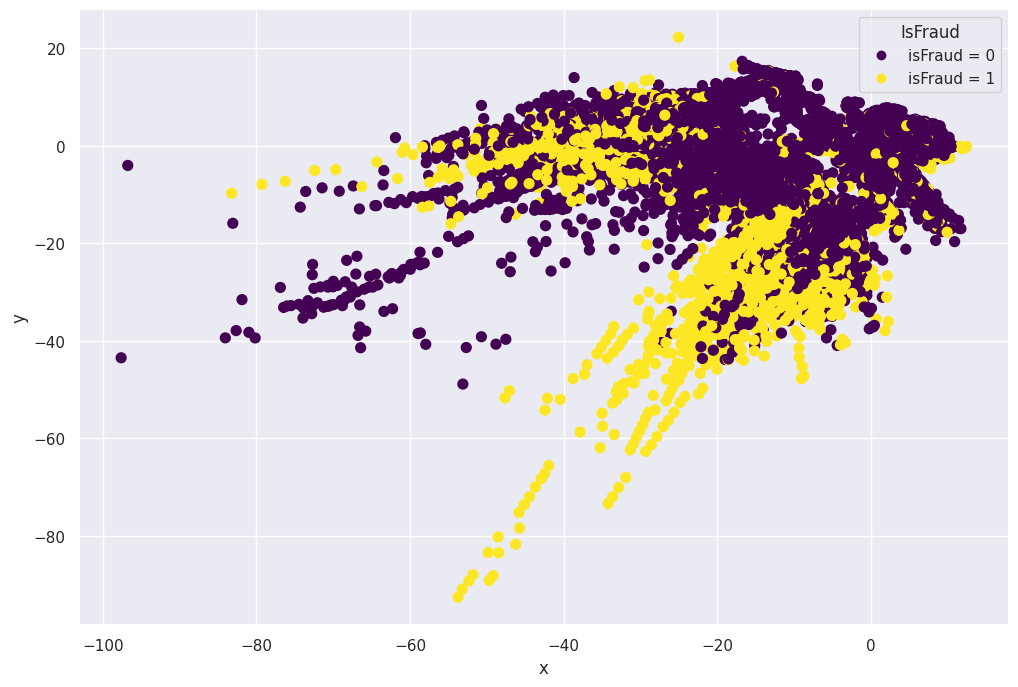

In [ ]:
plt.figure(figsize=(12,8))
sc = plt.scatter(X_train_2pca[:,0], X_train_2pca[:,1], c=y_train, s=50, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')

unique = np.unique(y_train)
handles, labels = sc.legend_elements()
plt.legend(handles, [f'isFraud = {c}' for c in unique], title="IsFraud")

plt.show()

Попробую применить KMeans на двух кластерах

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_scaled_enc)

KMeans(n_clusters=2, random_state=42)

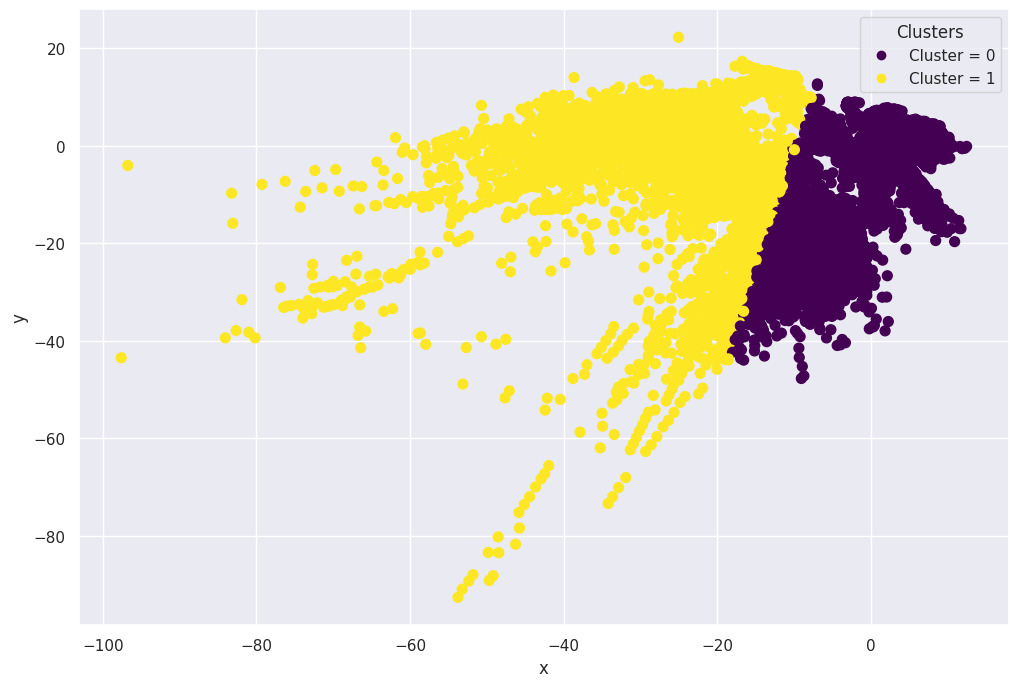

In [ ]:
plt.figure(figsize=(12,8))
sc = plt.scatter(X_train_2pca[:,0], X_train_2pca[:,1], c=kmeans.labels_, s=50, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')

unique = np.unique(kmeans.labels_)
handles, labels = sc.legend_elements()
plt.legend(handles, [f'Cluster = {c}' for c in unique], title="Clusters")

plt.show()

Стоит попробовать также больше кластеров, возможно, KMeans лучше отделит целевую переменную с большим количеством кластеров.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_train_scaled_enc)

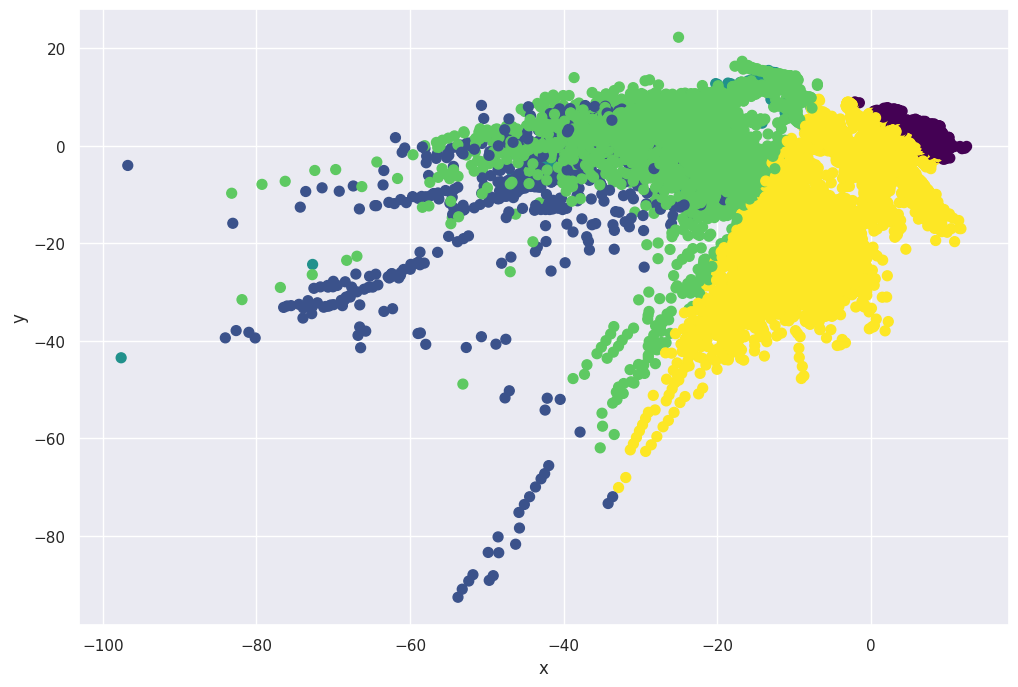

In [ ]:
plt.figure(figsize=(12,8))
sc = plt.scatter(X_train_2pca[:,0], X_train_2pca[:,1], c=kmeans.labels_, s=50, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

Проверю метрики для кластеров из KMeans

In [ ]:
from sklearn.metrics import homogeneity_completeness_v_measure

In [ ]:
homogeneity_completeness_v_measure(y_train.to_numpy(), kmeans.labels_)

(0.02443973223734784, 0.0034393848991045176, 0.006030151212025679)

Метрики очень плохие, лучше попробовать какой-то другой способ кластеризации. Для эксперимента добавлю данные кластеры как новый признак, закодированный TargetEncoder-ом

In [ ]:
X_train_enc_cluster = X_train_enc.copy()
X_test_enc_cluster = df_test_enc.copy()

te = TargetEncoder(smoothing=1)

X_train_enc_cluster['cluster'] = kmeans.labels_.astype(str)
X_test_enc_cluster['cluster'] = kmeans.predict(X_test_scaled_enc).astype(str)

X_train_enc_cluster['cluster'] = te.fit_transform(X_train_enc_cluster['cluster'], y_train)
X_test_enc_cluster['cluster'] = te.transform(X_test_enc_cluster['cluster'])

In [ ]:
lgbm = LGBMClassifier(
    random_state=42,
    objective='binary',
    force_row_wise=True,
    reg_alpha=3,
    num_leaves=150,
    n_estimators=100,
    min_child_samples=90,
    max_depth=-1,
    learning_rate=0.1
    )
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
scores = cross_val_score(lgbm, X_train_enc_cluster, y_train, scoring=scorer, cv=cv)

[LightGBM] [Info] Number of positive: 9814, number of negative: 268558
[LightGBM] [Info] Total Bins 34591
[LightGBM] [Info] Number of data points in the train set: 278372, number of used features: 463
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035255 -> initscore=-3.309257
[LightGBM] [Info] Start training from score -3.309257
[LightGBM] [Info] Number of positive: 9814, number of negative: 268559
[LightGBM] [Info] Total Bins 34739
[LightGBM] [Info] Number of data points in the train set: 278373, number of used features: 463
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035255 -> initscore=-3.309261
[LightGBM] [Info] Start training from score -3.309261
[LightGBM] [Info] Number of positive: 9814, number of negative: 268559
[LightGBM] [Info] Total Bins 34616
[LightGBM] [Info] Number of data points in the train set: 278373, number of used features: 463
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035255 -> initscore=-3.309261
[LightGBM] [Info] Start training from score -3.30

In [ ]:
scores.max(), scores.mean()

(0.9579177413965244, 0.954060252600863)

In [ ]:
lgbm.fit(X_train_enc_cluster, y_train)
predictions = lgbm.predict(X_test_enc_cluster)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_kmeans.csv', index=False)

**На кросс-валидации - 0.9579177413965244**
**На лидерборде - 0.68059**  
Результат близок к результатам с определением аномалий!

Попробую использовать HDBSCAN

In [ ]:
!pip install hdbscan -q

In [ ]:
import hdbscan

pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled_enc)
X_test_pca = pca.transform(X_test_scaled_enc)

hdb = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric='manhattan',
    cluster_selection_method='eom',
    prediction_data=True
)

In [ ]:
clusters = hdb.fit_predict(X_train_pca)

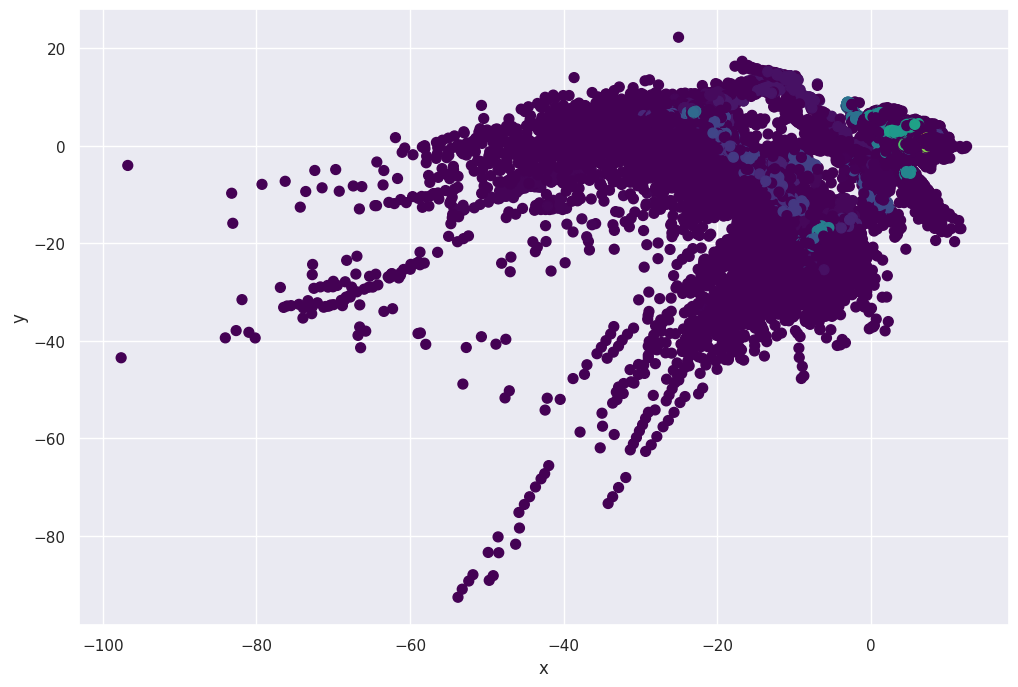

In [ ]:
plt.figure(figsize=(12,8))
sc = plt.scatter(X_train_2pca[:,0], X_train_2pca[:,1], c=clusters, s=50, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [ ]:
homogeneity_completeness_v_measure(y_train.to_numpy(), clusters)

(0.049781171683096766, 0.0030587833237398845, 0.005763434800835363)

Метрики кластеризации HDBSCAN тоже плохие, но немного лучше, чем для KMeans

Отдельно проверю кластер, отмеченный как аномалия

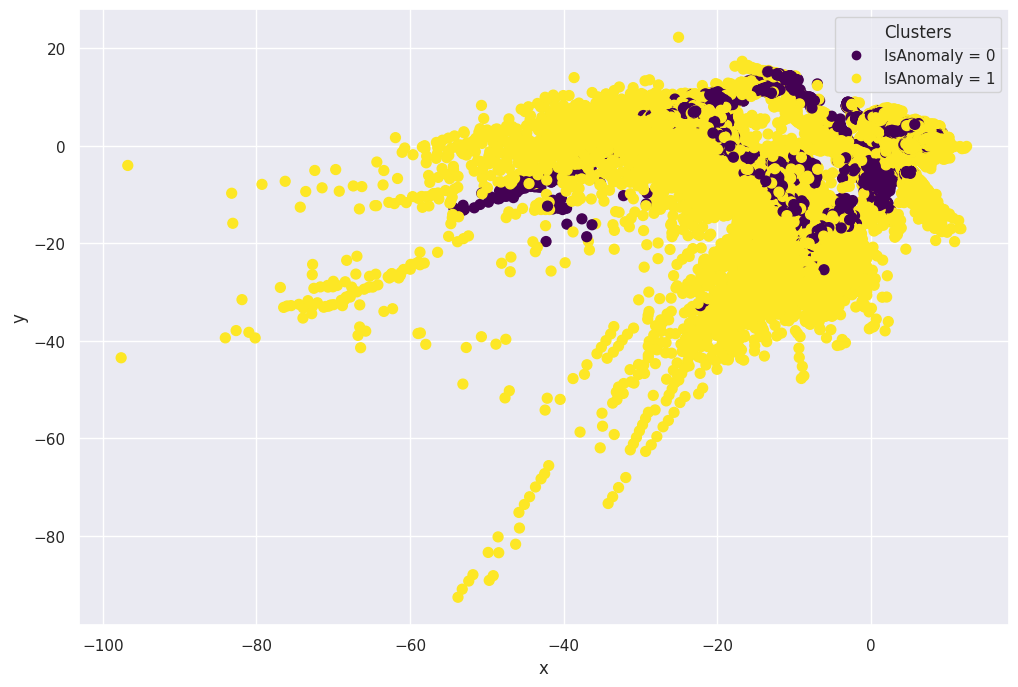

In [ ]:
plt.figure(figsize=(12,8))
anomalies = [1 if i==-1 else 0 for i in clusters]
sc = plt.scatter(X_train_2pca[:,0], X_train_2pca[:,1], c=anomalies, s=50, cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')

unique = np.unique(anomalies)
handles, labels = sc.legend_elements()
plt.legend(handles, [f'IsAnomaly = {c}' for c in unique], title="Clusters")

plt.show()

По картинке видно, что HDBSCAN отнес большое количество точек к шумам. Возможно, это связано с низкой плотностью точек

In [ ]:
from hdbscan import approximate_predict

test_clusters = approximate_predict(hdb, X_test_pca)

In [ ]:
X_train_enc_cluster = X_train_enc.copy()
X_test_enc_cluster = df_test_enc.copy()

X_train_enc_cluster['is_anomaly'] = [1 if i == -1 else 0 for i in clusters]
X_test_enc_cluster['is_anomaly'] = [1 if i == -1 else 0 for i in test_clusters[0]]

te = TargetEncoder(smoothing=1)

X_train_enc_cluster['cluster'] = clusters.astype(str)
X_test_enc_cluster['cluster'] = test_clusters[0].astype(str)

X_train_enc_cluster['cluster'] = te.fit_transform(X_train_enc_cluster['cluster'], y_train)
X_test_enc_cluster['cluster'] = te.transform(X_test_enc_cluster['cluster'])

In [ ]:
lgbm = LGBMClassifier(
    random_state=42,
    objective='binary',
    force_row_wise=True,
    reg_alpha=3,
    num_leaves=150,
    n_estimators=100,
    min_child_samples=90,
    max_depth=-1,
    learning_rate=0.1
    )
scorer = make_scorer(roc_auc_score, response_method="predict_proba")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
scores = cross_val_score(lgbm, X_train_enc_cluster, y_train, scoring=scorer, cv=cv)

In [ ]:
scores.max(), scores.mean()

(0.9575843453598606, 0.9547779566543045)

In [ ]:
lgbm.fit(X_train_enc_cluster, y_train)
predictions = lgbm.predict(X_test_enc_cluster)
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_hgbm.csv', index=False)

**На кросс-валидации - 0.9575843453598606**   
**На лидерборде - 0.68357**  
Новые признаки, полученные с помощью кластеров HDBSCAN помогли улучшить качество предсказания

**Вывод:** Получение новых признаков с помощью кластеризации дало небольшой прирост метрики roc-auc.

## **Задание 5 (1 балл)**

Примените какой-нибудь (один любой) AutoML фреймворк для решения поставленной задачи.

Отправьте AutoML-прогноз на kaggle и посмотрите на качество модели. Сделайте текстовые выводы.

Попробую использовать AutoGlugon  
https://auto.gluon.ai/stable/index.html

In [ ]:
!pip install autogluon -q

In [ ]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(label='isFraud', path='autogluon_model', eval_metric='roc_auc')

In [ ]:
train_data = X_train_enc.copy()
train_data['isFraud'] = y_train

In [ ]:
predictor.fit(
    train_data=train_data,
    time_limit=1800,
    presets='high_quality'
    )

In [ ]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1,0.931945,roc_auc,30.274757,941.778847,30.274757,941.778847,1,False,1
1,WeightedEnsemble_L2,0.931945,roc_auc,30.378654,946.721821,0.103897,4.942974,2,False,3
2,LightGBM_BAG_L1,0.797738,roc_auc,3.442769,307.954672,3.442769,307.954672,1,False,2
3,WeightedEnsemble_L2_FULL,NaN,roc_auc,NaN,119.651796,NaN,4.942974,2,True,6
4,LightGBM_BAG_L1_FULL,NaN,roc_auc,NaN,24.743712,NaN,24.743712,1,True,5
5,LightGBMXT_BAG_L1_FULL,NaN,roc_auc,NaN,114.708822,NaN,114.708822,1,True,4


In [ ]:
predictions = predictor.predict(df_test_enc)

In [ ]:
sub = pd.DataFrame({'TransactionID': df_test['TransactionID'], 'isFraud': predictions})
sub.to_csv('submission_automl.csv', index=False)

**На лидерборде  - 0.66503**  
**Вывод:** AutoML не смогла улучшить качество предсказания

# **Задание 6 (1 балл)**

Весь курс мы работали в Google Colab. Но всегда должны быть запасные варианты, где Вы будете обучать модели.

Среди вариантов есть:
* ваша локальная машина
* kaggle notebooks
* yandex cloud
и другие.

Кроме привычного Google Colab выберите из списка выше один любой альтернативный вариант и проведите эксперимент:

* Прогоните ваш лучший по качеству по результатам заданий 2-4 ML-пайплайн заново в Google Colab и с помощью библиотек (например, при помощи библиотеки time) замерьте время обучения и отдельно время инференса на тестовых данных

* Прогоните этот пайплайн на выбранном альтернативном сервисе/локальной машине и также замерьте время обучения и инференса.

Текстом напишите выводы: опишите, какое альтернативное место для обучения моделей Вы использовали? Прикрепите прямо в ноутбук скриншот с экраном кода в альтернативном сервисе/на локальной машине. Также в виде таблицы приведите сравнение времени обучения и инференса в колабе и в альтернативном месте. Сделайте выводы.

Буду обучать LightGBM с добавлением признака с кластерами KMeans, т.к. он показал лучший результат на кросс-валидации.

In [ ]:
X_train_enc = X_train_enc.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
df_test_enc = df_test_enc.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

Сперва в Google Colab

In [ ]:
start_time = time.time()

scaler = StandardScaler()
kmeans = KMeans(n_clusters=5, random_state=42)

X_train_scaled_enc = scaler.fit_transform(X_train_enc)
X_test_scaled_enc = scaler.transform(df_test_enc)

kmeans.fit(X_train_scaled_enc)


X_train_enc_cluster = X_train_enc.copy()
X_test_enc_cluster = df_test_enc.copy()

te = TargetEncoder(smoothing=1)

X_train_enc_cluster['cluster'] = kmeans.labels_.astype(str)
X_test_enc_cluster['cluster'] = kmeans.predict(X_test_scaled_enc).astype(str)

X_train_enc_cluster['cluster'] = te.fit_transform(X_train_enc_cluster['cluster'], y_train)
X_test_enc_cluster['cluster'] = te.transform(X_test_enc_cluster['cluster'])

lgbm = LGBMClassifier(
    random_state=42,
    objective='binary',
    force_row_wise=True,
    reg_alpha=3,
    num_leaves=150,
    n_estimators=100,
    min_child_samples=90,
    max_depth=-1,
    learning_rate=0.1,
    verbose=0
    )

lgbm.fit(X_train_enc_cluster, y_train)

end_time = time.time() - start_time
print("Время на обучение пайплайна:", end_time)

Время на обучение пайплайна: 74.70204138755798


In [ ]:
start_time = time.time()
lgbm.predict(X_test_enc_cluster)
end_time = time.time() - start_time
print("Время на предсказание:", end_time)

Время на предсказание: 2.3909366130828857


Также проверю на Kaggle

In [ ]:
start_time = time.time()

scaler = StandardScaler()
kmeans = KMeans(n_clusters=5, random_state=42)

X_train_scaled_enc = scaler.fit_transform(X_train_enc)
X_test_scaled_enc = scaler.transform(df_test_enc)

kmeans.fit(X_train_scaled_enc)


X_train_enc_cluster = X_train_enc.copy()
X_test_enc_cluster = df_test_enc.copy()

te = TargetEncoder(smoothing=1)

X_train_enc_cluster['cluster'] = kmeans.labels_.astype(str)
X_test_enc_cluster['cluster'] = kmeans.predict(X_test_scaled_enc).astype(str)

X_train_enc_cluster['cluster'] = te.fit_transform(X_train_enc_cluster['cluster'], y_train)
X_test_enc_cluster['cluster'] = te.transform(X_test_enc_cluster['cluster'])

lgbm = LGBMClassifier(
    random_state=42,
    objective='binary',
    force_row_wise=True,
    reg_alpha=3,
    num_leaves=150,
    n_estimators=100,
    min_child_samples=90,
    max_depth=-1,
    learning_rate=0.1,
    verbose=0
    )

lgbm.fit(X_train_enc_cluster, y_train)

end_time = time.time() - start_time
print("Время на обучение пайплайна:", end_time)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Время на обучение пайплайна: 112.89043188095093


In [ ]:
start_time = time.time()
lgbm.predict(X_test_enc_cluster)
end_time = time.time() - start_time
print("Время на предсказание:", end_time)

Время на предсказание: 2.522686004638672


**Вывод:** В Google Colab пайплайн сработал немного быстрее. Но в Kaggle доступно больше оперативной памяти (30ГБ, а в Colab - 12ГБ), что часто бывает полезно.

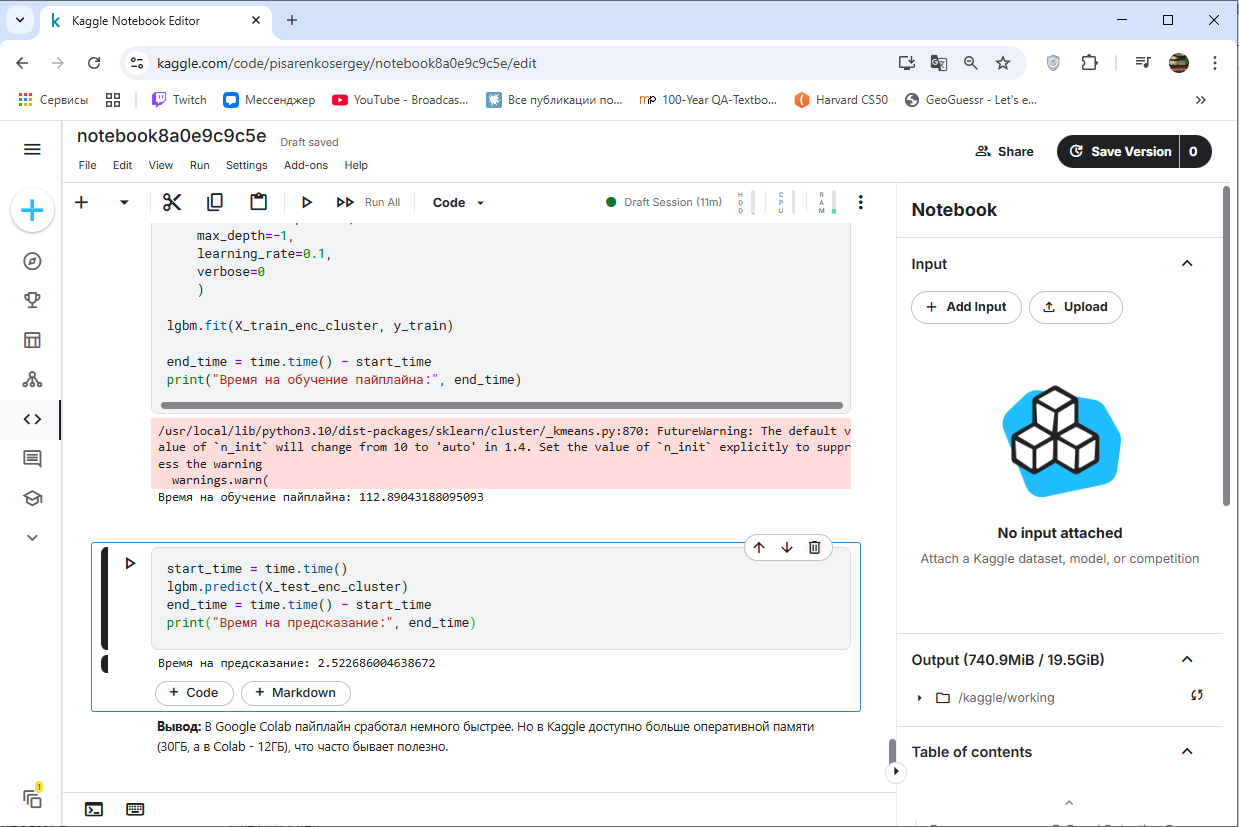

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/Kaggle.png'))

# **Бонус: за Kaggle и стремление к хорошим скорам (2 балла)**

В этом домашнем задании Ваша цель - не просто выполнить шаги выше, но и построить максимально хорошую по качеству модель.

**К 10 вы можете получить до двух дополнительных баллов:**

* За попадание в топ-20% на private leaderboard — +1 дополнительный балл к оценке
* За попадание в топ-5 мест на private leaderboard — + еще один дополнительный балл к оценке (то есть суммарно 2 дополнительных балла)

**ВАЖНО!!!**

Эти баллы ставятся до мягкого дедлайна по соревнованию. После мягкого дедлайна лидерборд не обновляется, и дополнительные баллы не ставятся.

Успехов!

In [ ]:
# не забудьте прикрепить скриншоты лидерборда, пожалуйста